In [1]:
# !unzip -o -q ./data/deepseek-new.zip -d ./data/

## Dependencies

In [1]:
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from icecream import ic

import os

## Data Preparing

In [2]:
df_labled = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')
df_labled.head()

,id,label
0,44263a6b,Scyther
1,9b6344f2,Butterfree
2,c89ffbde,Rhydon
3,95bbd7ff,Koffing
4,c3e8a9e1,Dewgong


In [3]:
df_test.head()

,id
0,9553b359
1,c6bcf2c2
2,5493d25f
3,f17f13b5
4,bb4e5386


### EDA

In [4]:
df_labled.shape

(5243, 2)

In [5]:
df_labled['label'].nunique()

150

<Axes: xlabel='label', ylabel='Count'>

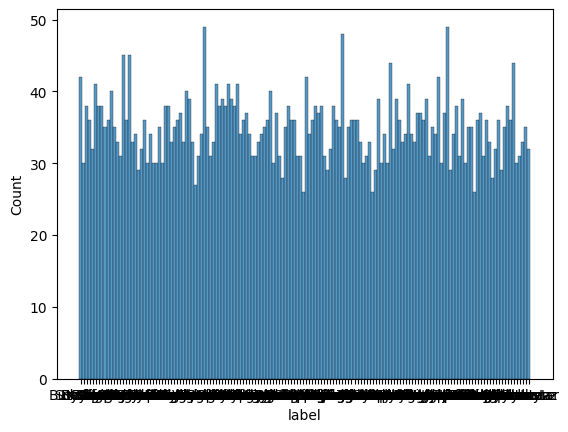

In [6]:
sns.histplot(df_labled, x='label')

In [7]:
df_train, df_val = train_test_split(df_labled, test_size=0.3, stratify=df_labled['label'], shuffle=True, random_state=42)
df_train.shape, df_val.shape

((3670, 2), (1573, 2))

<Axes: xlabel='label', ylabel='count'>

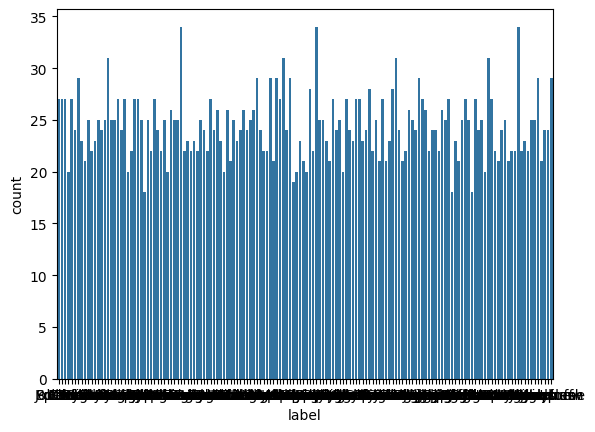

In [8]:
sns.countplot(data=df_train, x='label')

<Axes: xlabel='label', ylabel='count'>

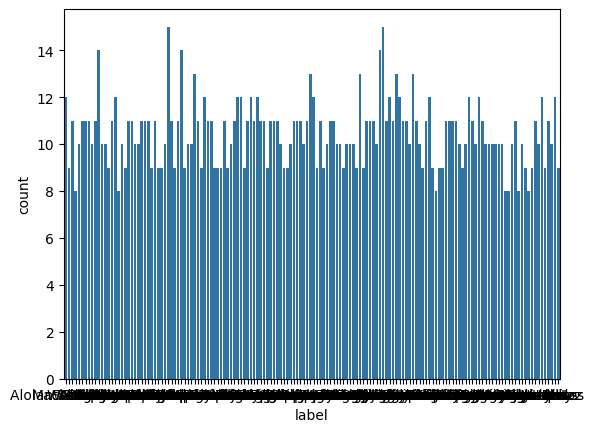

In [9]:
sns.countplot(data=df_val, x='label')

In [10]:
label_encoder = LabelEncoder()
label_encoder.fit(df_labled['label'])

LabelEncoder()

In [11]:
label_encoder.inverse_transform([0])

array(['Abra'], dtype=object)

In [12]:
label_encoder.transform(['Abra'])

array([0])

### Custom Dataset & Transforms

In [13]:
class PockemonDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_path: str, transform: transforms.Compose = None, is_test = False):
        super().__init__()

        self.df = df
        self.img_path = img_path
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, index):
        id = self.df.iloc[index]['id']
        label = 0
        if not self.is_test:
            label = self.df.iloc[index]['label']
            label = label_encoder.transform([label])[0]

        img_path = os.path.join(self.img_path, f"{id}.jpg")
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return (img, label)

In [14]:
IN_SHAPE = (128, 128)

train_transforms = transforms.Compose([
    transforms.Resize(IN_SHAPE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomRotation(20),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(IN_SHAPE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### DataLoaders

In [15]:
train_dataset = PockemonDataset(df_train, "./data/train", train_transforms)
val_dataset = PockemonDataset(df_val, "./data/train", test_transforms)
test_dataset = PockemonDataset(df_test, "./data/test", test_transforms, is_test=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].


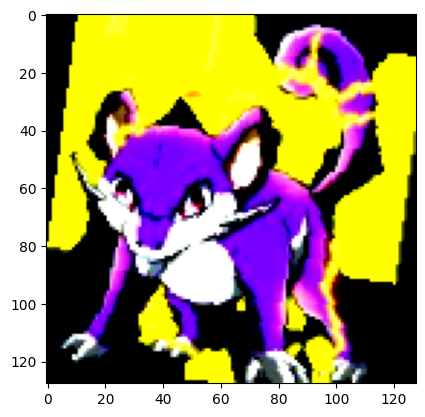

In [16]:
img_idx = np.random.randint(0, len(train_dataset))
img = train_dataset[img_idx][0].numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img)

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, persistent_workers=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8, persistent_workers=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

## Training

### Train Loop

In [18]:
def train_loop(
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        optimizer: torch.optim.AdamW,
        criterion = nn.CrossEntropyLoss(),
        num_epoches = 100,
        model_name = "best_model.pth"
    ):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_metrics = []

    for epoch in trange(num_epoches):
        model.train()
        cur_train_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)

            optimizer.zero_grad()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            cur_train_loss += loss.item()
        
        train_losses.append(cur_train_loss / len(train_loader))
        
        model.eval()
        cur_val_loss = 0.
        cur_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)

                loss = criterion(y_pred, y_batch)
                cur_val_loss += loss.item()

                y_pred = y_pred.detach().cpu().numpy()
                y_pred = np.argmax(y_pred, axis=1)
                y_batch = y_batch.cpu().numpy()

                val_labels.extend(y_batch)
                cur_preds.extend(y_pred)

        val_losses.append(cur_val_loss / len(val_loader))
        cur_metric = f1_score(val_labels, cur_preds, average='macro')
        if len(val_metrics) < 2 or cur_metric > max(val_metrics):
            torch.save(model.state_dict(), f"./models/{model_name}")
            print("!!! NEW BEST MODEL !!!")
        val_metrics.append(cur_metric)

        print(f"Epoch {epoch}: train_loss {train_losses[-1]}, val_loss {val_losses[-1]}, val_f1 {cur_metric}")
        
        if epoch % 10 == 0 or epoch == num_epoches - 1:
            if epoch == 0:
                continue
            
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label='Train')
            axs[0].plot(val_losses, label='Val')
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("val F1-score")
            axs[1].plot(val_metrics)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()

    print(f"Best score: {max(val_metrics)}")

    return model


### Model

In [19]:
class PockemonModel(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            out_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(PockemonModel, self).__init__()

        self.img_shape = img_shape
        self.in_ch = in_ch

        conv_layers = [
            nn.Conv2d(in_ch, hidden_ch[0], 3, 1, 1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU(),
            nn.Conv2d(hidden_ch[0], hidden_ch[0], 3, 1, 1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(conv_dropout)
        ]
        last_ch = hidden_ch[0]
        for ch in hidden_ch[1:]:
            conv_layers.extend([
                nn.Conv2d(last_ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                nn.Conv2d(ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(conv_dropout)
            ])
            last_ch = ch

        self.conv_net = nn.Sequential(*conv_layers)
        
        fc_layers = []
        last_dim = self._shape_after_conv(self.conv_net)
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout1d(fc_dropout)
            ])
            last_dim = dim
        fc_layers.extend([
            nn.Linear(last_dim, out_dim)
        ])

        self.fc_net = nn.Sequential(*fc_layers)
        
    def forward(self, x):
        x = self.conv_net(x)
        flatten = nn.Flatten()
        x = flatten(x)
        x = self.fc_net(x)
        return x


    def _shape_after_conv(self, conv_block: nn.Module):
        A = torch.zeros(size=(1, self.in_ch, *self.img_shape))
        A = conv_block(A)
        flatten = nn.Flatten()
        A = flatten(A)
        return A.shape[1]
        


ic| PockemonModel(
        img_shape=IN_SHAPE,
        in_ch=3,
        hidden_ch=[32, 64, 128, 256],
        hidden_fc=[],
        out_dim=150,
        conv_dropout=0.1
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (5): ReLU()
           (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (7): Dropout2d(p=0.1, inplace=False)
           (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (10): ReLU()
           (11): MaxPool2d(kernel

!!! NEW BEST MODEL !!!
Epoch 0: train_loss 4.843631547072838, val_loss 4.332631441263052, val_f1 0.022804883888977733


  1%|          | 2/200 [00:05<08:39,  2.62s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 4.127052734638083, val_loss 3.603956864430354, val_f1 0.08022545517202152


  2%|▏         | 3/200 [00:07<08:05,  2.46s/it]

!!! NEW BEST MODEL !!!
Epoch 2: train_loss 3.5796478781206855, val_loss 3.2392547864180345, val_f1 0.14237506062013186


  2%|▏         | 4/200 [00:09<07:45,  2.38s/it]

!!! NEW BEST MODEL !!!
Epoch 3: train_loss 3.162883659888958, val_loss 2.7926600712996263, val_f1 0.24347750170856672


  2%|▎         | 5/200 [00:12<07:34,  2.33s/it]

!!! NEW BEST MODEL !!!
Epoch 4: train_loss 2.8214047777241675, val_loss 2.635795024725107, val_f1 0.28665248217078326


  3%|▎         | 6/200 [00:14<07:26,  2.30s/it]

!!! NEW BEST MODEL !!!
Epoch 5: train_loss 2.541524286927848, val_loss 2.3608842262854943, val_f1 0.34024114382206405


  4%|▎         | 7/200 [00:16<07:21,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 6: train_loss 2.2605051254404, val_loss 2.1334437406980076, val_f1 0.41240301041966454


  4%|▍         | 8/200 [00:18<07:17,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 7: train_loss 2.0557621511919746, val_loss 1.9971067630327666, val_f1 0.46465798367783917


  4%|▍         | 9/200 [00:21<07:14,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 8: train_loss 1.8811875951701198, val_loss 1.9064829441217275, val_f1 0.48909850997283855


  5%|▌         | 10/200 [00:23<07:10,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 9: train_loss 1.704837075595198, val_loss 1.7159192562103271, val_f1 0.5411768608878517
Epoch 10: train_loss 1.5303265267405017, val_loss 1.6552537037776067, val_f1 0.538057549090131


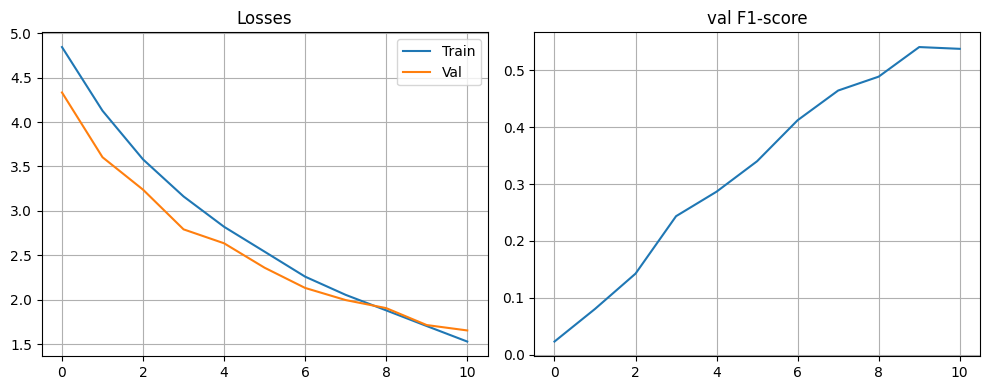

  6%|▌         | 12/200 [00:28<07:09,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 11: train_loss 1.423759674203807, val_loss 1.6273463781063373, val_f1 0.5476607114737174


  6%|▋         | 13/200 [00:30<07:05,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 1.2528060613007381, val_loss 1.4960021514158983, val_f1 0.590429086714657


  7%|▋         | 14/200 [00:32<07:02,  2.27s/it]

Epoch 13: train_loss 1.1570541570926536, val_loss 1.5312126049628625, val_f1 0.5770127965822011


  8%|▊         | 15/200 [00:34<06:58,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 14: train_loss 1.056718150089527, val_loss 1.4818318440363958, val_f1 0.6000817150668442


  8%|▊         | 16/200 [00:37<06:55,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 15: train_loss 0.9437276494914087, val_loss 1.4242225701992328, val_f1 0.6182994860305161


  8%|▊         | 17/200 [00:39<06:52,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 16: train_loss 0.8641358161794728, val_loss 1.3715702387002797, val_f1 0.6334828136543809


  9%|▉         | 18/200 [00:41<06:49,  2.25s/it]

!!! NEW BEST MODEL !!!
Epoch 17: train_loss 0.8229282477806354, val_loss 1.3361016420217662, val_f1 0.6367733860894308


 10%|▉         | 19/200 [00:43<06:47,  2.25s/it]

!!! NEW BEST MODEL !!!
Epoch 18: train_loss 0.7373244721314003, val_loss 1.3042289568827703, val_f1 0.6636971870611651


 10%|█         | 20/200 [00:46<06:44,  2.25s/it]

Epoch 19: train_loss 0.6784690824048273, val_loss 1.2921946048736572, val_f1 0.6537319424020317
Epoch 20: train_loss 0.622653301419883, val_loss 1.3640076380509596, val_f1 0.6355856049259366


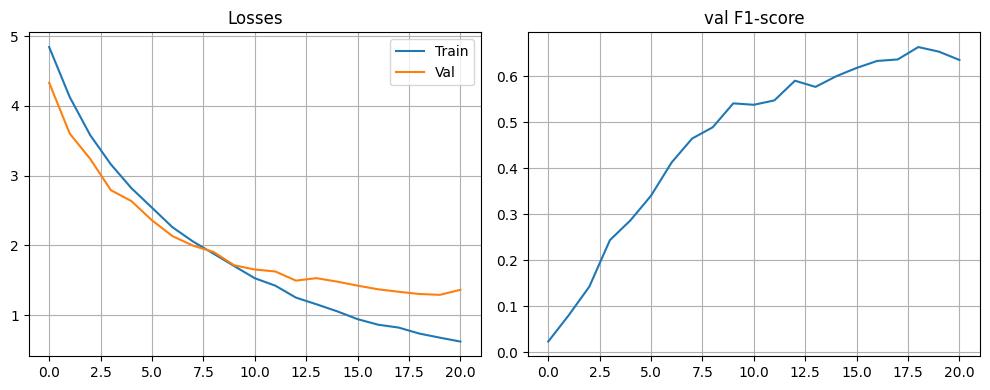

 11%|█         | 22/200 [00:50<06:43,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 21: train_loss 0.578668482344726, val_loss 1.2408496416532075, val_f1 0.6641391686897848


 12%|█▏        | 23/200 [00:52<06:39,  2.26s/it]

Epoch 22: train_loss 0.519830577332398, val_loss 1.2659306526184082, val_f1 0.6588420195479598


 12%|█▏        | 24/200 [00:55<06:37,  2.26s/it]

Epoch 23: train_loss 0.47475379294362563, val_loss 1.2505435943603516, val_f1 0.6582724746126668


 12%|█▎        | 25/200 [00:57<06:34,  2.25s/it]

Epoch 24: train_loss 0.45121903768901167, val_loss 1.289004426736098, val_f1 0.6541758402595564


 13%|█▎        | 26/200 [00:59<06:31,  2.25s/it]

!!! NEW BEST MODEL !!!
Epoch 25: train_loss 0.3984621013032979, val_loss 1.2163020739188561, val_f1 0.6751283893214279


 14%|█▎        | 27/200 [01:01<06:29,  2.25s/it]

Epoch 26: train_loss 0.365624011590563, val_loss 1.2715196701196523, val_f1 0.667999793903134


 14%|█▍        | 28/200 [01:04<06:27,  2.25s/it]

!!! NEW BEST MODEL !!!
Epoch 27: train_loss 0.35016747487002403, val_loss 1.2460157779546885, val_f1 0.6815431891631762


 14%|█▍        | 29/200 [01:06<06:25,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 28: train_loss 0.32310670973925754, val_loss 1.1696724616564238, val_f1 0.6863893600992199


 15%|█▌        | 30/200 [01:08<06:24,  2.26s/it]

Epoch 29: train_loss 0.27402115125080634, val_loss 1.2046135343038118, val_f1 0.6776749720133576
Epoch 30: train_loss 0.2700563936397947, val_loss 1.191444837130033, val_f1 0.6767928561193496


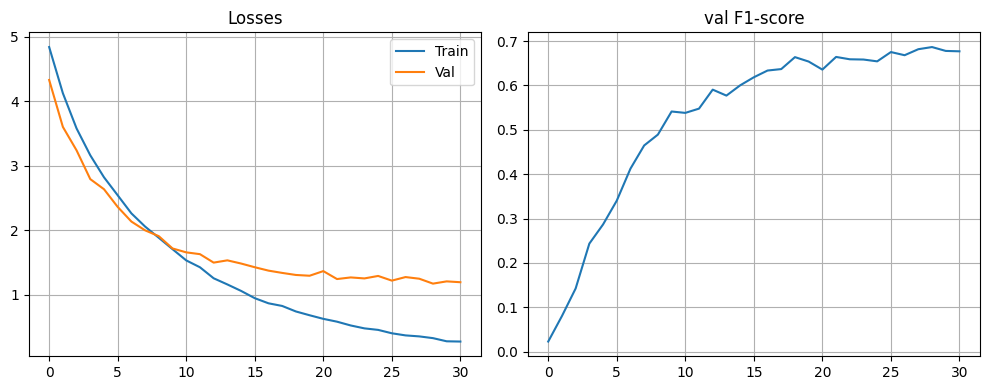

 16%|█▌        | 32/200 [01:13<06:22,  2.28s/it]

Epoch 31: train_loss 0.2385412804011641, val_loss 1.2246831013606145, val_f1 0.68296892856069


 16%|█▋        | 33/200 [01:15<06:18,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 32: train_loss 0.24023102172489824, val_loss 1.1743829112786512, val_f1 0.689944974527959


 17%|█▋        | 34/200 [01:17<06:16,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 33: train_loss 0.22725699019843135, val_loss 1.177772962130033, val_f1 0.6900428636329872


 18%|█▊        | 35/200 [01:20<06:14,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 34: train_loss 0.20543068647384644, val_loss 1.1628734882061298, val_f1 0.6984634286542831


 18%|█▊        | 36/200 [01:22<06:11,  2.27s/it]

Epoch 35: train_loss 0.20368095769964414, val_loss 1.2059037960492647, val_f1 0.6908585357987195


 18%|█▊        | 37/200 [01:24<06:09,  2.26s/it]

Epoch 36: train_loss 0.18930113161432333, val_loss 1.2325001083887541, val_f1 0.6829385089192475


 19%|█▉        | 38/200 [01:26<06:05,  2.26s/it]

Epoch 37: train_loss 0.17128776938750825, val_loss 1.2108797476841853, val_f1 0.6770461649343691


 20%|█▉        | 39/200 [01:29<06:02,  2.25s/it]

!!! NEW BEST MODEL !!!
Epoch 38: train_loss 0.16971397451285658, val_loss 1.1989115063960736, val_f1 0.6994489034576339


 20%|██        | 40/200 [01:31<06:00,  2.25s/it]

Epoch 39: train_loss 0.1867693493078495, val_loss 1.206122902723459, val_f1 0.689165918702886
Epoch 40: train_loss 0.17568178963044595, val_loss 1.2325736375955434, val_f1 0.6835878166676571


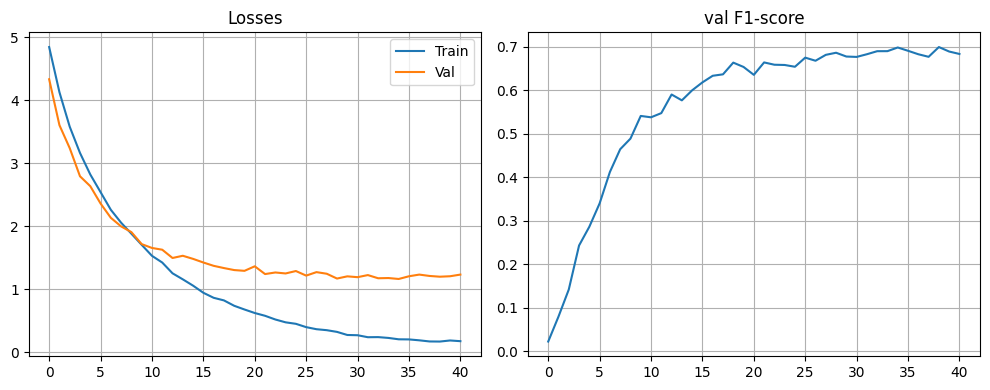

 21%|██        | 42/200 [01:35<06:00,  2.28s/it]

Epoch 41: train_loss 0.13163521269272113, val_loss 1.218279453424307, val_f1 0.6950734114396664


 22%|██▏       | 43/200 [01:38<05:56,  2.27s/it]

Epoch 42: train_loss 0.12431276384098776, val_loss 1.2222781777381897, val_f1 0.6986250720109004


 22%|██▏       | 44/200 [01:40<05:54,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 43: train_loss 0.1206274204726877, val_loss 1.1863647607656627, val_f1 0.7008015564725395


 22%|██▎       | 45/200 [01:42<05:51,  2.27s/it]

Epoch 44: train_loss 0.12108709303469493, val_loss 1.2167531251907349, val_f1 0.6990145077442176


 23%|██▎       | 46/200 [01:45<05:50,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 45: train_loss 0.12653019150783276, val_loss 1.2041957286687999, val_f1 0.7046715314836268


 24%|██▎       | 47/200 [01:47<05:47,  2.27s/it]

Epoch 46: train_loss 0.1271920247838415, val_loss 1.241891929736504, val_f1 0.6947669296010053


 24%|██▍       | 48/200 [01:49<05:44,  2.27s/it]

Epoch 47: train_loss 0.11331987458056417, val_loss 1.2464020343927236, val_f1 0.6957959659069378


 24%|██▍       | 49/200 [01:51<05:42,  2.27s/it]

Epoch 48: train_loss 0.11182692197376284, val_loss 1.2727441420921912, val_f1 0.6906146971460407


 25%|██▌       | 50/200 [01:54<05:39,  2.26s/it]

Epoch 49: train_loss 0.089324242339052, val_loss 1.2242456491176898, val_f1 0.7016909560110031
Epoch 50: train_loss 0.096988327544311, val_loss 1.251978759582226, val_f1 0.6971997650841882


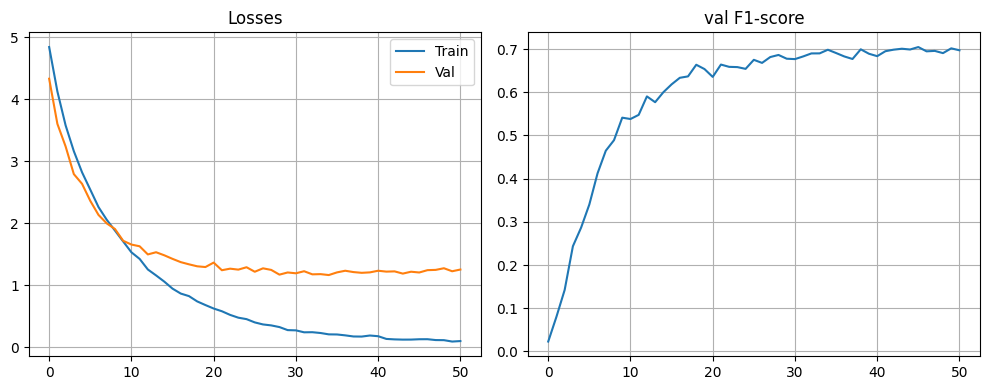

 26%|██▌       | 52/200 [01:58<05:37,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 51: train_loss 0.08769824355840683, val_loss 1.2239109140176039, val_f1 0.7087273713132226


 26%|██▋       | 53/200 [02:00<05:33,  2.27s/it]

Epoch 52: train_loss 0.09158944133026846, val_loss 1.2751874832006602, val_f1 0.6911396657931228


 27%|██▋       | 54/200 [02:03<05:31,  2.27s/it]

Epoch 53: train_loss 0.08543243670258029, val_loss 1.2361004856916575, val_f1 0.7038605975114843


 28%|██▊       | 55/200 [02:05<05:28,  2.26s/it]

Epoch 54: train_loss 0.08617550648491958, val_loss 1.272002045924847, val_f1 0.6953676605721172


 28%|██▊       | 56/200 [02:07<05:25,  2.26s/it]

Epoch 55: train_loss 0.0840408188001863, val_loss 1.2368710545393138, val_f1 0.692342521829483


 28%|██▊       | 57/200 [02:09<05:22,  2.26s/it]

Epoch 56: train_loss 0.07925386585552117, val_loss 1.2697373628616333, val_f1 0.6916786710882741


 29%|██▉       | 58/200 [02:12<05:19,  2.25s/it]

Epoch 57: train_loss 0.08341464079145727, val_loss 1.2575423304851239, val_f1 0.696024002765847


 30%|██▉       | 59/200 [02:14<05:17,  2.25s/it]

Epoch 58: train_loss 0.0887119777757546, val_loss 1.273807351405804, val_f1 0.6891592905014976


 30%|███       | 60/200 [02:16<05:15,  2.25s/it]

Epoch 59: train_loss 0.08335122286245741, val_loss 1.2560235216067388, val_f1 0.6886350689166882
Epoch 60: train_loss 0.0808085336767394, val_loss 1.2643780066416814, val_f1 0.6989910482539705


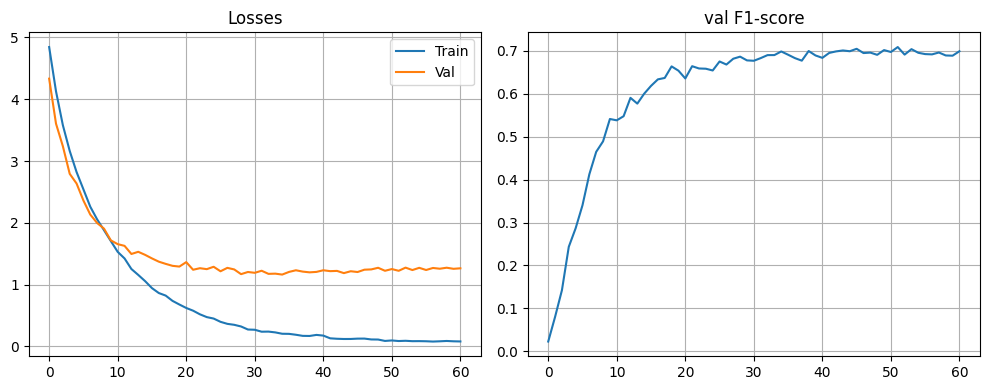

 31%|███       | 62/200 [02:21<05:13,  2.27s/it]

Epoch 61: train_loss 0.07759476632907472, val_loss 1.2570444574722877, val_f1 0.6983819938977295


 32%|███▏      | 63/200 [02:23<05:09,  2.26s/it]

Epoch 62: train_loss 0.07870464116848748, val_loss 1.24257892370224, val_f1 0.7037615170604613


 32%|███▏      | 64/200 [02:25<05:07,  2.26s/it]

Epoch 63: train_loss 0.07072121662826374, val_loss 1.311479417177347, val_f1 0.6884717288142032


 32%|███▎      | 65/200 [02:28<05:04,  2.26s/it]

Epoch 64: train_loss 0.08402659178807817, val_loss 1.2689628234276404, val_f1 0.6863661802243367


 33%|███▎      | 66/200 [02:30<05:03,  2.27s/it]

Epoch 65: train_loss 0.07508484877902886, val_loss 1.278298258781433, val_f1 0.6968202707967986


 34%|███▎      | 67/200 [02:32<05:00,  2.26s/it]

Epoch 66: train_loss 0.08665278386966936, val_loss 1.3039197830053477, val_f1 0.690090721773336


 34%|███▍      | 68/200 [02:34<04:58,  2.26s/it]

Epoch 67: train_loss 0.08164746134445586, val_loss 1.2743060955634484, val_f1 0.7036871810852946


 34%|███▍      | 69/200 [02:37<04:55,  2.26s/it]

Epoch 68: train_loss 0.0785069976901186, val_loss 1.2473265849626982, val_f1 0.7009673676792717


 35%|███▌      | 70/200 [02:39<04:53,  2.25s/it]

Epoch 69: train_loss 0.0813027367252728, val_loss 1.2622062884844267, val_f1 0.7029636819792174
Epoch 70: train_loss 0.07665273701322489, val_loss 1.2677672092731183, val_f1 0.6895942070069714


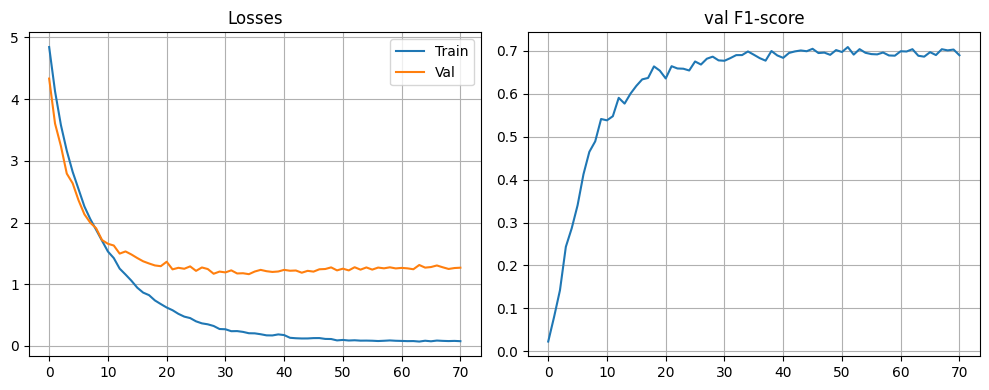

 36%|███▌      | 72/200 [02:43<04:52,  2.28s/it]

Epoch 71: train_loss 0.08424775893318243, val_loss 1.2918098981563861, val_f1 0.6990862125576911


 36%|███▋      | 73/200 [02:46<04:48,  2.27s/it]

Epoch 72: train_loss 0.07195734701536853, val_loss 1.2932071869189923, val_f1 0.7080058632124689


 37%|███▋      | 74/200 [02:48<04:45,  2.27s/it]

Epoch 73: train_loss 0.06801605622830062, val_loss 1.2625556221375098, val_f1 0.706096226827281


 38%|███▊      | 75/200 [02:50<04:42,  2.26s/it]

Epoch 74: train_loss 0.06656129240732768, val_loss 1.2946276297936072, val_f1 0.7085733892753804


 38%|███▊      | 76/200 [02:53<04:40,  2.26s/it]

Epoch 75: train_loss 0.0645509363505347, val_loss 1.3204351938687837, val_f1 0.6929919543219811


 38%|███▊      | 77/200 [02:55<04:37,  2.26s/it]

Epoch 76: train_loss 0.06604368811280563, val_loss 1.273954153060913, val_f1 0.6984087388203617


 39%|███▉      | 78/200 [02:57<04:35,  2.26s/it]

Epoch 77: train_loss 0.0702385114955491, val_loss 1.3274200696211595, val_f1 0.6926729384956716


 40%|███▉      | 79/200 [02:59<04:32,  2.25s/it]

Epoch 78: train_loss 0.07324500793013079, val_loss 1.3908877281042247, val_f1 0.6745370716615632


 40%|████      | 80/200 [03:01<04:30,  2.25s/it]

Epoch 79: train_loss 0.07926665888778095, val_loss 1.3481255036133986, val_f1 0.6980889105699604
Epoch 80: train_loss 0.06803955600179475, val_loss 1.3033782518826997, val_f1 0.6948721801987713


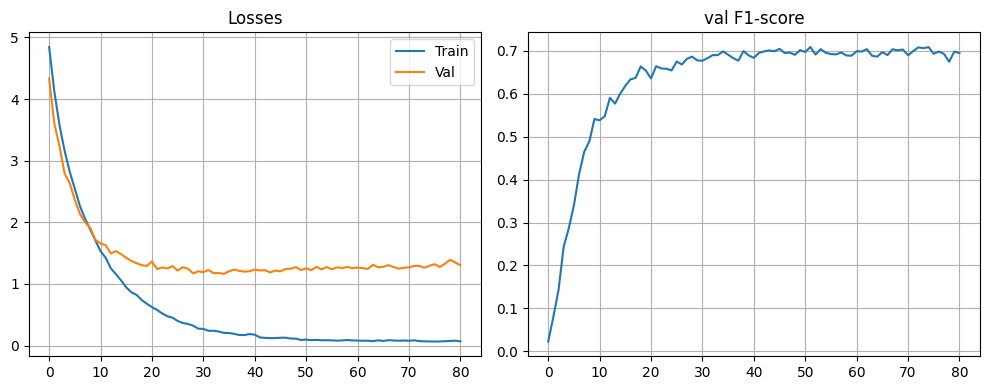

 41%|████      | 82/200 [03:06<04:28,  2.28s/it]

Epoch 81: train_loss 0.05623689460857161, val_loss 1.3354917672964244, val_f1 0.6889267574605701


 42%|████▏     | 83/200 [03:08<04:25,  2.27s/it]

Epoch 82: train_loss 0.058651049974663506, val_loss 1.2926995204045222, val_f1 0.6986296794022727


 42%|████▏     | 84/200 [03:11<04:22,  2.26s/it]

Epoch 83: train_loss 0.06146024161114775, val_loss 1.3107771552526033, val_f1 0.6992855365595818


 42%|████▎     | 85/200 [03:13<04:19,  2.26s/it]

Epoch 84: train_loss 0.06976566540783849, val_loss 1.3335025493915265, val_f1 0.6981485321243183


 43%|████▎     | 86/200 [03:15<04:17,  2.25s/it]

Epoch 85: train_loss 0.06105131167789985, val_loss 1.3537885684233446, val_f1 0.6960645045350753


 44%|████▎     | 87/200 [03:17<04:14,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 86: train_loss 0.057983944642132725, val_loss 1.3125956241901104, val_f1 0.7110178792908816


 44%|████▍     | 88/200 [03:20<04:12,  2.25s/it]

Epoch 87: train_loss 0.05199268421736257, val_loss 1.3456869583863478, val_f1 0.7011264634787295


 44%|████▍     | 89/200 [03:22<04:10,  2.26s/it]

Epoch 88: train_loss 0.05338695574680279, val_loss 1.2694455476907582, val_f1 0.7096214291928074


 45%|████▌     | 90/200 [03:24<04:08,  2.26s/it]

Epoch 89: train_loss 0.051897992925911116, val_loss 1.2975759368676405, val_f1 0.7044647745252117
Epoch 90: train_loss 0.055560023748669134, val_loss 1.3053097908313458, val_f1 0.6984535228967245


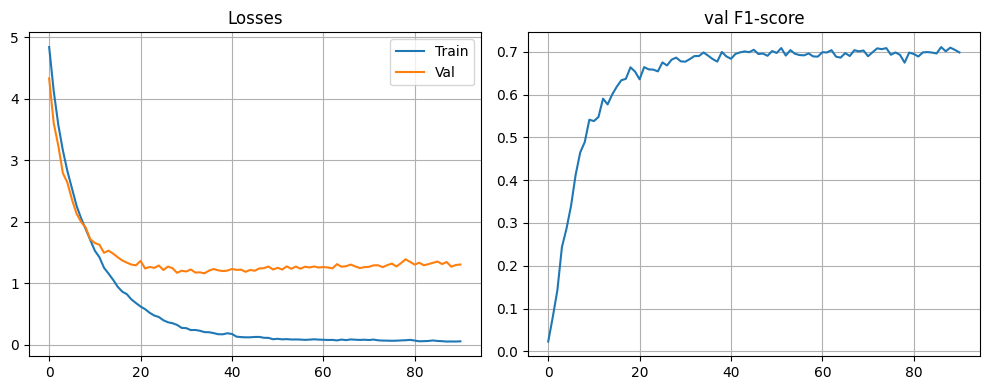

 46%|████▌     | 92/200 [03:29<04:05,  2.28s/it]

Epoch 91: train_loss 0.052345301634792625, val_loss 1.3191317594968355, val_f1 0.701404411466759


 46%|████▋     | 93/200 [03:31<04:02,  2.27s/it]

Epoch 92: train_loss 0.045945250268640186, val_loss 1.2860382428536048, val_f1 0.7077145812965271


 47%|████▋     | 94/200 [03:33<04:00,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 93: train_loss 0.045481329687453546, val_loss 1.3149572106508107, val_f1 0.7135166370738187


 48%|████▊     | 95/200 [03:36<03:57,  2.26s/it]

Epoch 94: train_loss 0.047495663551421, val_loss 1.2864817564304059, val_f1 0.7124059433681994


 48%|████▊     | 96/200 [03:38<03:54,  2.26s/it]

Epoch 95: train_loss 0.04259056713560532, val_loss 1.3104498386383057, val_f1 0.7117889821139834


 48%|████▊     | 97/200 [03:40<03:52,  2.25s/it]

Epoch 96: train_loss 0.05418858497307218, val_loss 1.3351293618862445, val_f1 0.695900901518082


 49%|████▉     | 98/200 [03:42<03:49,  2.25s/it]

Epoch 97: train_loss 0.05838069049962636, val_loss 1.3423692904985869, val_f1 0.6968185206111974


 50%|████▉     | 99/200 [03:44<03:47,  2.25s/it]

Epoch 98: train_loss 0.06344246260564902, val_loss 1.424098354119521, val_f1 0.6995321736401238


 50%|█████     | 100/200 [03:47<03:45,  2.25s/it]

Epoch 99: train_loss 0.0720204911997606, val_loss 1.3861424831243663, val_f1 0.7048915108450634
Epoch 100: train_loss 0.0630767550640579, val_loss 1.351858065678523, val_f1 0.6964189070839669


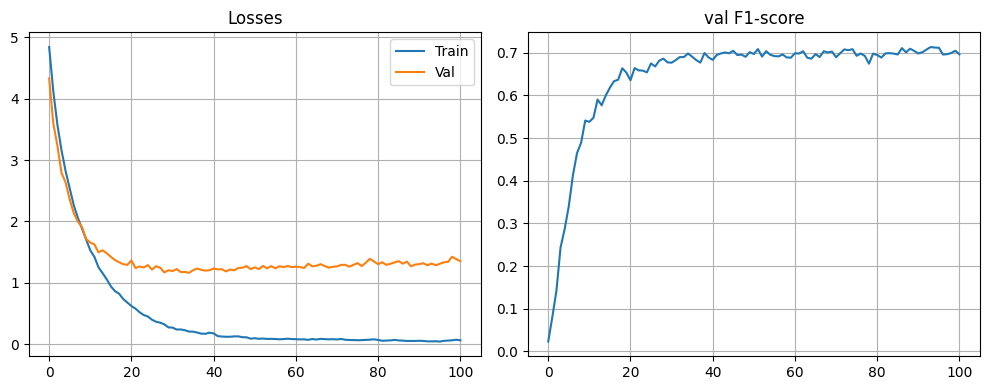

 51%|█████     | 102/200 [03:51<03:43,  2.28s/it]

Epoch 101: train_loss 0.05858496332476879, val_loss 1.3040106571637666, val_f1 0.713062402413638


 52%|█████▏    | 103/200 [03:54<03:39,  2.27s/it]

Epoch 102: train_loss 0.04690749795529349, val_loss 1.3301987556310801, val_f1 0.7077838676670845


 52%|█████▏    | 104/200 [03:56<03:36,  2.26s/it]

Epoch 103: train_loss 0.05379636097570945, val_loss 1.3483967781066895, val_f1 0.7070238058421516


 52%|█████▎    | 105/200 [03:58<03:34,  2.26s/it]

Epoch 104: train_loss 0.05478875155978162, val_loss 1.3868163915780873, val_f1 0.7035454127255589


 53%|█████▎    | 106/200 [04:00<03:32,  2.26s/it]

Epoch 105: train_loss 0.0526347512957351, val_loss 1.3580973652692943, val_f1 0.7107594495228183


 54%|█████▎    | 107/200 [04:03<03:29,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 106: train_loss 0.05163752236242952, val_loss 1.362203102845412, val_f1 0.7155719975374404


 54%|█████▍    | 108/200 [04:05<03:27,  2.25s/it]

Epoch 107: train_loss 0.040196585565291605, val_loss 1.3398001010601337, val_f1 0.7124224433931531


 55%|█████▍    | 109/200 [04:07<03:25,  2.25s/it]

Epoch 108: train_loss 0.04560536390234684, val_loss 1.3676106562981238, val_f1 0.709794959131051


 55%|█████▌    | 110/200 [04:09<03:22,  2.25s/it]

Epoch 109: train_loss 0.05346975851290185, val_loss 1.3768271207809448, val_f1 0.7043706229273613
Epoch 110: train_loss 0.05776663362209139, val_loss 1.344900158735422, val_f1 0.7148144087893378


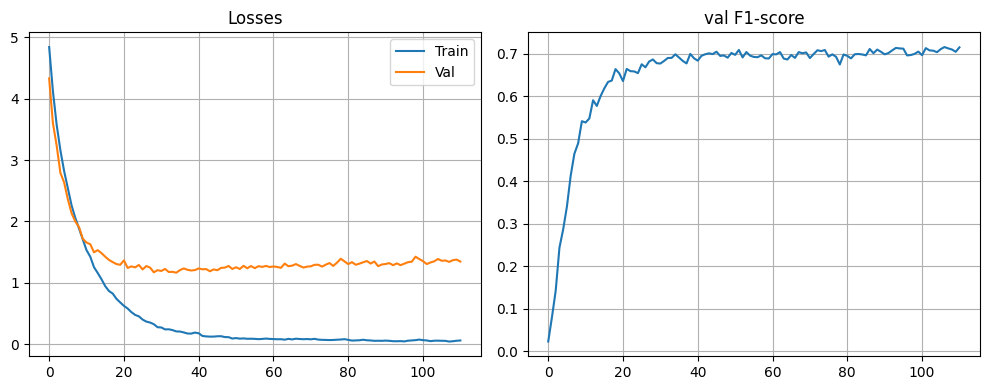

 56%|█████▌    | 112/200 [04:14<03:20,  2.28s/it]

Epoch 111: train_loss 0.051290264224697804, val_loss 1.383539887575003, val_f1 0.7040150254943678


 56%|█████▋    | 113/200 [04:16<03:17,  2.27s/it]

Epoch 112: train_loss 0.06322461565763786, val_loss 1.4292897169406598, val_f1 0.6866434987472183


 57%|█████▋    | 114/200 [04:18<03:14,  2.27s/it]

Epoch 113: train_loss 0.07742303121706536, val_loss 1.4395924256398127, val_f1 0.6955477569792894


 57%|█████▊    | 115/200 [04:21<03:11,  2.26s/it]

Epoch 114: train_loss 0.06760157721823659, val_loss 1.3852829841467051, val_f1 0.7093387339149757


 58%|█████▊    | 116/200 [04:23<03:09,  2.26s/it]

Epoch 115: train_loss 0.04810642418933326, val_loss 1.3863153457641602, val_f1 0.6954461684089913


 58%|█████▊    | 117/200 [04:25<03:07,  2.26s/it]

Epoch 116: train_loss 0.04697455073995837, val_loss 1.3348762805645282, val_f1 0.71138252811989


 59%|█████▉    | 118/200 [04:27<03:04,  2.25s/it]

Epoch 117: train_loss 0.03658390131875359, val_loss 1.3264440298080444, val_f1 0.7117826968251384


 60%|█████▉    | 119/200 [04:30<03:02,  2.25s/it]

Epoch 118: train_loss 0.05007603334198738, val_loss 1.3554117954694307, val_f1 0.709541559408229


 60%|██████    | 120/200 [04:32<03:00,  2.25s/it]

Epoch 119: train_loss 0.0467774521174102, val_loss 1.3787934688421397, val_f1 0.7067465876879951
Epoch 120: train_loss 0.06346901454802217, val_loss 1.417448823268597, val_f1 0.689741264891426


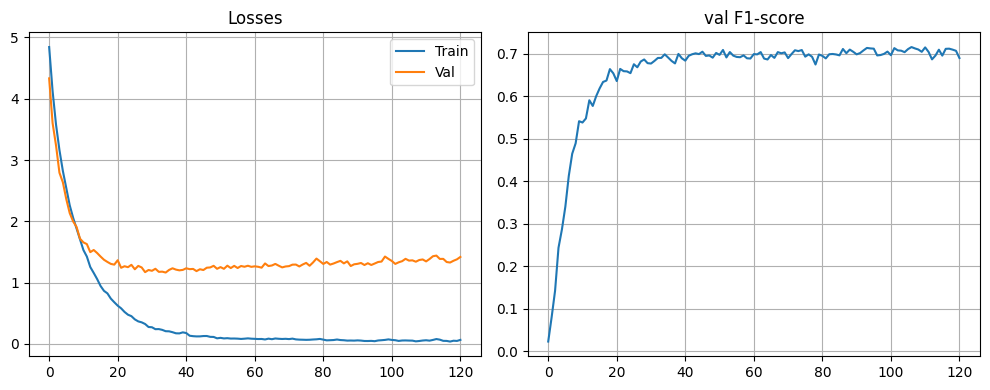

 61%|██████    | 122/200 [04:37<02:59,  2.30s/it]

Epoch 121: train_loss 0.05897346440831135, val_loss 1.43840898000277, val_f1 0.694606547523897


 62%|██████▏   | 123/200 [04:39<02:56,  2.29s/it]

Epoch 122: train_loss 0.05557883132634492, val_loss 1.5056066329662616, val_f1 0.6856399621111927


 62%|██████▏   | 124/200 [04:41<02:53,  2.28s/it]

Epoch 123: train_loss 0.04186960136325195, val_loss 1.37447334252871, val_f1 0.6982901246379456


 62%|██████▎   | 125/200 [04:43<02:50,  2.27s/it]

Epoch 124: train_loss 0.03748586610088061, val_loss 1.4015816358419566, val_f1 0.7020669063122384


 63%|██████▎   | 126/200 [04:46<02:47,  2.27s/it]

Epoch 125: train_loss 0.05328888555282149, val_loss 1.4441579030110285, val_f1 0.6967056068214666


 64%|██████▎   | 127/200 [04:48<02:45,  2.26s/it]

Epoch 126: train_loss 0.03841954000808041, val_loss 1.353956910280081, val_f1 0.706298171253142


 64%|██████▍   | 128/200 [04:50<02:42,  2.26s/it]

Epoch 127: train_loss 0.03869264932542012, val_loss 1.3782160373834462, val_f1 0.7039299727652538


 64%|██████▍   | 129/200 [04:53<02:40,  2.26s/it]

Epoch 128: train_loss 0.045930927458765175, val_loss 1.4411033667050874, val_f1 0.698623132081308


 65%|██████▌   | 130/200 [04:55<02:38,  2.26s/it]

Epoch 129: train_loss 0.05631782853140913, val_loss 1.5272985421694243, val_f1 0.6885206344749425
Epoch 130: train_loss 0.046655818563083123, val_loss 1.4625006455641527, val_f1 0.6929528773024788


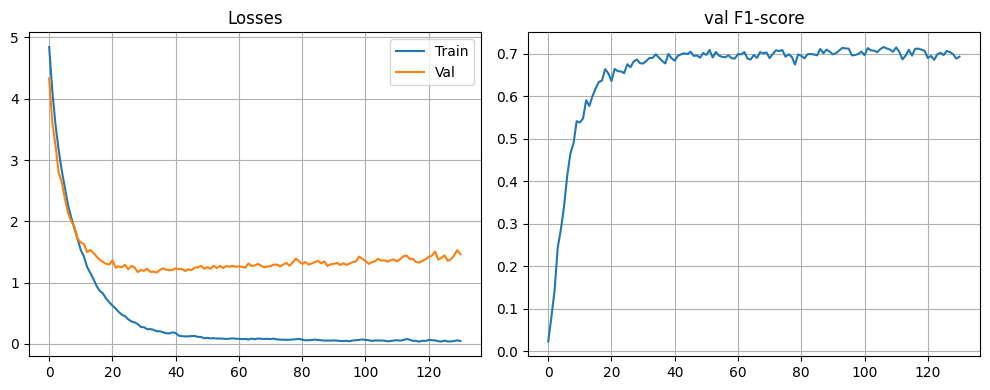

 66%|██████▌   | 132/200 [04:59<02:35,  2.28s/it]

Epoch 131: train_loss 0.03540924878726746, val_loss 1.4154356809762807, val_f1 0.7042277918829691


 66%|██████▋   | 133/200 [05:02<02:32,  2.28s/it]

Epoch 132: train_loss 0.03177161122961291, val_loss 1.4521292814841638, val_f1 0.6982182368441109


 67%|██████▋   | 134/200 [05:04<02:30,  2.28s/it]

Epoch 133: train_loss 0.04566942396220462, val_loss 1.4816826581954956, val_f1 0.6985583172587616


 68%|██████▊   | 135/200 [05:06<02:27,  2.27s/it]

Epoch 134: train_loss 0.03481015550165341, val_loss 1.4743396318875825, val_f1 0.6945027124959463


 68%|██████▊   | 136/200 [05:08<02:25,  2.27s/it]

Epoch 135: train_loss 0.03571117133030604, val_loss 1.4185196161270142, val_f1 0.7101653947350584


 68%|██████▊   | 137/200 [05:11<02:22,  2.26s/it]

Epoch 136: train_loss 0.03457941662455941, val_loss 1.5331879762502818, val_f1 0.6841054055137913


 69%|██████▉   | 138/200 [05:13<02:20,  2.26s/it]

Epoch 137: train_loss 0.03728363829953917, val_loss 1.4645280196116521, val_f1 0.7033822974756784


 70%|██████▉   | 139/200 [05:15<02:17,  2.26s/it]

Epoch 138: train_loss 0.04021503798792075, val_loss 1.4760002631407518, val_f1 0.6909547131439526


 70%|███████   | 140/200 [05:17<02:15,  2.26s/it]

Epoch 139: train_loss 0.04638012896837859, val_loss 1.4891910094481249, val_f1 0.6986185755014926
Epoch 140: train_loss 0.05478494331754487, val_loss 1.5391213527092567, val_f1 0.6823024666400748


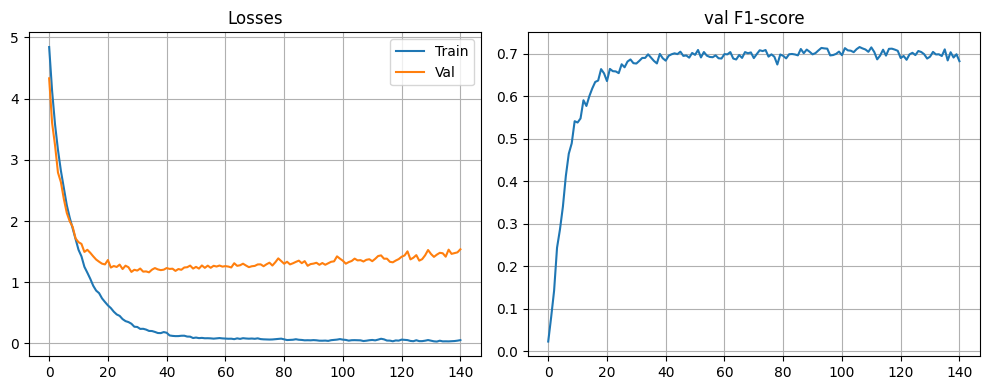

 71%|███████   | 142/200 [05:22<02:13,  2.29s/it]

Epoch 141: train_loss 0.045424580574035645, val_loss 1.5122727980980506, val_f1 0.7025817306281742


 72%|███████▏  | 143/200 [05:24<02:10,  2.29s/it]

Epoch 142: train_loss 0.04398293035297558, val_loss 1.503414117372953, val_f1 0.7019707760305351


 72%|███████▏  | 144/200 [05:27<02:07,  2.28s/it]

Epoch 143: train_loss 0.04340286575386237, val_loss 1.5347206684259267, val_f1 0.6971822169503216


 72%|███████▎  | 145/200 [05:29<02:04,  2.27s/it]

Epoch 144: train_loss 0.04085221237920482, val_loss 1.523489603629479, val_f1 0.6939647052390453


 73%|███████▎  | 146/200 [05:31<02:02,  2.26s/it]

Epoch 145: train_loss 0.05117692579996997, val_loss 1.5759336398198054, val_f1 0.6912272700361698


 74%|███████▎  | 147/200 [05:33<01:59,  2.26s/it]

Epoch 146: train_loss 0.05868227953283951, val_loss 1.4481736788382897, val_f1 0.7060919384979024


 74%|███████▍  | 148/200 [05:36<01:57,  2.26s/it]

Epoch 147: train_loss 0.05148216696648762, val_loss 1.4329834993068988, val_f1 0.713122694111678


 74%|███████▍  | 149/200 [05:38<01:55,  2.26s/it]

Epoch 148: train_loss 0.05265282370663922, val_loss 1.482040946300213, val_f1 0.7086615217069163


 75%|███████▌  | 150/200 [05:40<01:52,  2.26s/it]

Epoch 149: train_loss 0.04172239921473224, val_loss 1.4307433458474965, val_f1 0.7056432103017937
Epoch 150: train_loss 0.04483023250539755, val_loss 1.4676512388082652, val_f1 0.6990180741088606


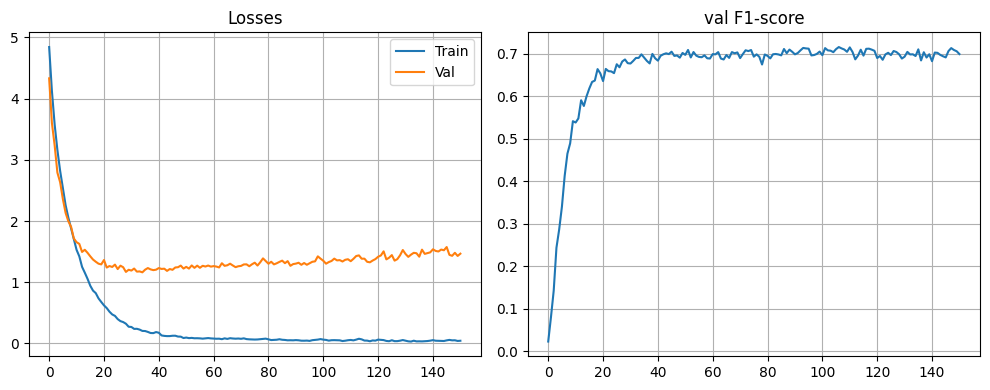

 76%|███████▌  | 152/200 [05:45<01:49,  2.28s/it]

Epoch 151: train_loss 0.057289279547744786, val_loss 1.625343524492704, val_f1 0.6772501289426405


 76%|███████▋  | 153/200 [05:47<01:46,  2.27s/it]

Epoch 152: train_loss 0.056976181519185674, val_loss 1.4232973960729747, val_f1 0.7088155076030068


 77%|███████▋  | 154/200 [05:49<01:44,  2.27s/it]

Epoch 153: train_loss 0.04548267589817787, val_loss 1.4429958967062144, val_f1 0.7024785520822022


 78%|███████▊  | 155/200 [05:52<01:41,  2.26s/it]

Epoch 154: train_loss 0.044486267909664534, val_loss 1.4950931530732374, val_f1 0.6940556305048136


 78%|███████▊  | 156/200 [05:54<01:39,  2.26s/it]

Epoch 155: train_loss 0.04335819236163435, val_loss 1.4259280791649451, val_f1 0.7096236981041866


 78%|███████▊  | 157/200 [05:56<01:37,  2.26s/it]

!!! NEW BEST MODEL !!!
Epoch 156: train_loss 0.03922476934204842, val_loss 1.4204873213401208, val_f1 0.7159565171105953


 79%|███████▉  | 158/200 [05:58<01:34,  2.26s/it]

Epoch 157: train_loss 0.044769705048409, val_loss 1.4093650762851422, val_f1 0.7109326032392957


 80%|███████▉  | 159/200 [06:01<01:32,  2.25s/it]

Epoch 158: train_loss 0.03975335935708778, val_loss 1.4337275945223296, val_f1 0.7065389905192002


 80%|████████  | 160/200 [06:03<01:30,  2.25s/it]

Epoch 159: train_loss 0.036125222028329455, val_loss 1.4088597572766817, val_f1 0.70437276107098
Epoch 160: train_loss 0.032631296503903534, val_loss 1.460002871660086, val_f1 0.7084778462998091


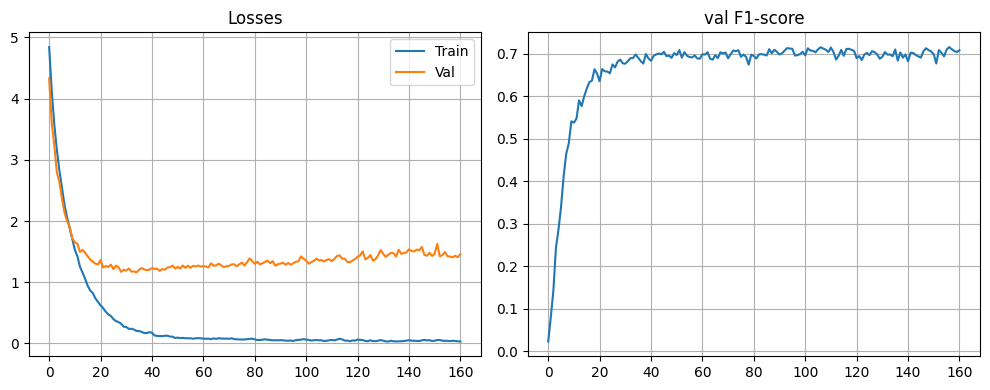

 81%|████████  | 162/200 [06:07<01:26,  2.27s/it]

Epoch 161: train_loss 0.037865350215599454, val_loss 1.3914136336399958, val_f1 0.7054493245422122


 82%|████████▏ | 163/200 [06:10<01:23,  2.27s/it]

Epoch 162: train_loss 0.03712570066724358, val_loss 1.399592427107004, val_f1 0.7040754714837938


 82%|████████▏ | 164/200 [06:12<01:21,  2.26s/it]

Epoch 163: train_loss 0.03715482379855781, val_loss 1.469295620918274, val_f1 0.7033135152730123


 82%|████████▎ | 165/200 [06:14<01:18,  2.26s/it]

Epoch 164: train_loss 0.036088524129370164, val_loss 1.4369839154756987, val_f1 0.6962592409224662


 83%|████████▎ | 166/200 [06:16<01:16,  2.25s/it]

Epoch 165: train_loss 0.041592089973133184, val_loss 1.4868494730729322, val_f1 0.7055388127364506


 84%|████████▎ | 167/200 [06:19<01:14,  2.25s/it]

Epoch 166: train_loss 0.036771480829037466, val_loss 1.5110732867167547, val_f1 0.7149867260063271


 84%|████████▍ | 168/200 [06:21<01:12,  2.25s/it]

Epoch 167: train_loss 0.0567846620326926, val_loss 1.4291628965964684, val_f1 0.7070061898612033


 84%|████████▍ | 169/200 [06:23<01:09,  2.25s/it]

Epoch 168: train_loss 0.05005994419856318, val_loss 1.5217481209681585, val_f1 0.7024094747919696


 85%|████████▌ | 170/200 [06:25<01:07,  2.26s/it]

Epoch 169: train_loss 0.055046622545040884, val_loss 1.533677944770226, val_f1 0.6972197015436071
Epoch 170: train_loss 0.053337011229375314, val_loss 1.511054121530973, val_f1 0.6946317274179319


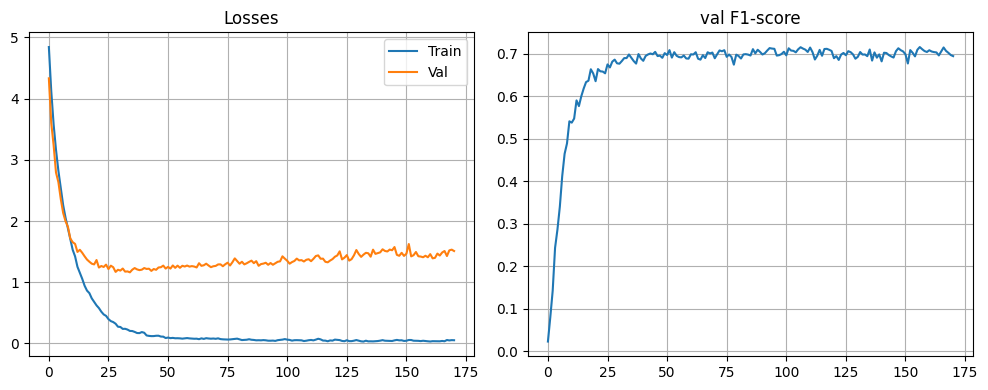

 86%|████████▌ | 172/200 [06:30<01:03,  2.28s/it]

Epoch 171: train_loss 0.04080457616083581, val_loss 1.4937109488707323, val_f1 0.7154167024742583


 86%|████████▋ | 173/200 [06:32<01:01,  2.28s/it]

Epoch 172: train_loss 0.042768242479912164, val_loss 1.5170239026729877, val_f1 0.7101060945702967


 87%|████████▋ | 174/200 [06:35<00:59,  2.28s/it]

Epoch 173: train_loss 0.04162232105716549, val_loss 1.5490312026097224, val_f1 0.7054283446310518


 88%|████████▊ | 175/200 [06:37<00:56,  2.27s/it]

Epoch 174: train_loss 0.04046402235740218, val_loss 1.571101115300105, val_f1 0.7027693593766395


 88%|████████▊ | 176/200 [06:39<00:54,  2.26s/it]

Epoch 175: train_loss 0.031842610670317864, val_loss 1.5162130227455726, val_f1 0.7061871835656875


 88%|████████▊ | 177/200 [06:41<00:51,  2.25s/it]

Epoch 176: train_loss 0.030481253204674555, val_loss 1.6034747728934655, val_f1 0.7050691230259717


 89%|████████▉ | 178/200 [06:44<00:49,  2.25s/it]

Epoch 177: train_loss 0.04031135899753406, val_loss 1.553295639845041, val_f1 0.6972002959732096


 90%|████████▉ | 179/200 [06:46<00:47,  2.25s/it]

Epoch 178: train_loss 0.04224553835931523, val_loss 1.520271897315979, val_f1 0.7070672539082513


 90%|█████████ | 180/200 [06:48<00:45,  2.25s/it]

Epoch 179: train_loss 0.03361829084440552, val_loss 1.5688368723942683, val_f1 0.6923738140966844
Epoch 180: train_loss 0.03578817927888755, val_loss 1.497791941349323, val_f1 0.7115120000752023


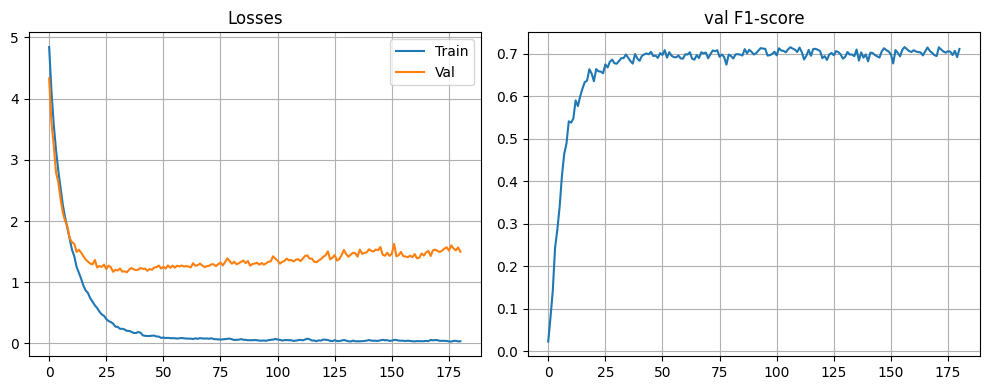

 91%|█████████ | 182/200 [06:53<00:40,  2.27s/it]

Epoch 181: train_loss 0.03353926346733652, val_loss 1.5866264563340406, val_f1 0.6973974915090835


 92%|█████████▏| 183/200 [06:55<00:38,  2.27s/it]

Epoch 182: train_loss 0.024062997227984256, val_loss 1.5328119901510386, val_f1 0.6997644064127757


 92%|█████████▏| 184/200 [06:57<00:36,  2.27s/it]

Epoch 183: train_loss 0.03265942935028981, val_loss 1.5473136810156016, val_f1 0.704433475960776


 92%|█████████▎| 185/200 [06:59<00:33,  2.26s/it]

Epoch 184: train_loss 0.030866274513818067, val_loss 1.5689296263914843, val_f1 0.7005182659895093


 93%|█████████▎| 186/200 [07:02<00:31,  2.26s/it]

Epoch 185: train_loss 0.03295517828443955, val_loss 1.5617292844332182, val_f1 0.7047679544333865


 94%|█████████▎| 187/200 [07:04<00:29,  2.27s/it]

Epoch 186: train_loss 0.027418369828755486, val_loss 1.4620409562037542, val_f1 0.7085577160909857


 94%|█████████▍| 188/200 [07:06<00:27,  2.28s/it]

Epoch 187: train_loss 0.03256166244632211, val_loss 1.496571760911208, val_f1 0.7023184673798387


 94%|█████████▍| 189/200 [07:09<00:24,  2.27s/it]

Epoch 188: train_loss 0.031261222372794974, val_loss 1.5019120986645038, val_f1 0.7036134235896087


 95%|█████████▌| 190/200 [07:11<00:22,  2.26s/it]

Epoch 189: train_loss 0.028680514447904867, val_loss 1.5241362681755652, val_f1 0.7109243293569693
Epoch 190: train_loss 0.03152341922295505, val_loss 1.5614290971022387, val_f1 0.6964614634842309


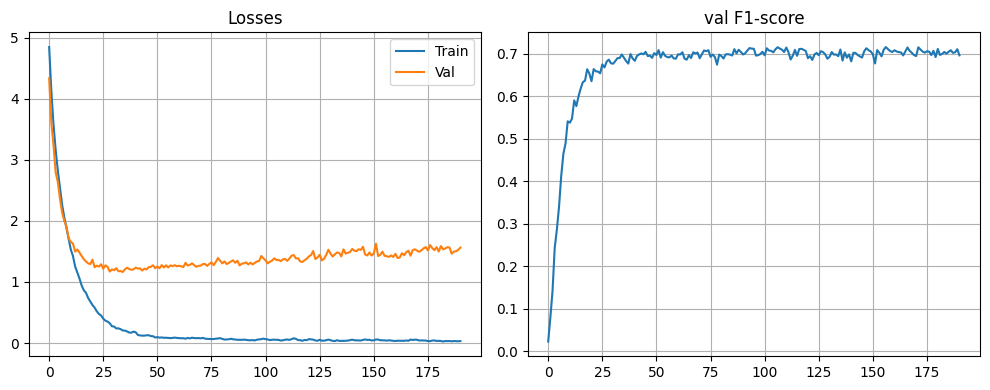

 96%|█████████▌| 192/200 [07:15<00:18,  2.28s/it]

Epoch 191: train_loss 0.035954567732225204, val_loss 1.519562473663917, val_f1 0.7129091021880045


 96%|█████████▋| 193/200 [07:18<00:15,  2.28s/it]

Epoch 192: train_loss 0.028208040921338672, val_loss 1.4736783596185536, val_f1 0.700132975882608


 97%|█████████▋| 194/200 [07:20<00:13,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 193: train_loss 0.0297134129394745, val_loss 1.4670387689883893, val_f1 0.7162372730157119


 98%|█████████▊| 195/200 [07:22<00:11,  2.26s/it]

Epoch 194: train_loss 0.02548678628779177, val_loss 1.4979520669350257, val_f1 0.7091721476287232


 98%|█████████▊| 196/200 [07:24<00:09,  2.26s/it]

Epoch 195: train_loss 0.0381610488262156, val_loss 1.581679289157574, val_f1 0.7054796600836366


 98%|█████████▊| 197/200 [07:27<00:06,  2.26s/it]

Epoch 196: train_loss 0.0352575547254548, val_loss 1.527522976581867, val_f1 0.7081232397967432


 99%|█████████▉| 198/200 [07:29<00:04,  2.25s/it]

Epoch 197: train_loss 0.038396893936241495, val_loss 1.5023027658462524, val_f1 0.709181796940993


100%|█████████▉| 199/200 [07:31<00:02,  2.25s/it]

Epoch 198: train_loss 0.03744589158430182, val_loss 1.4741086409642146, val_f1 0.7057879537227643
Epoch 199: train_loss 0.02538991823856687, val_loss 1.4952647961102998, val_f1 0.7011778867337266


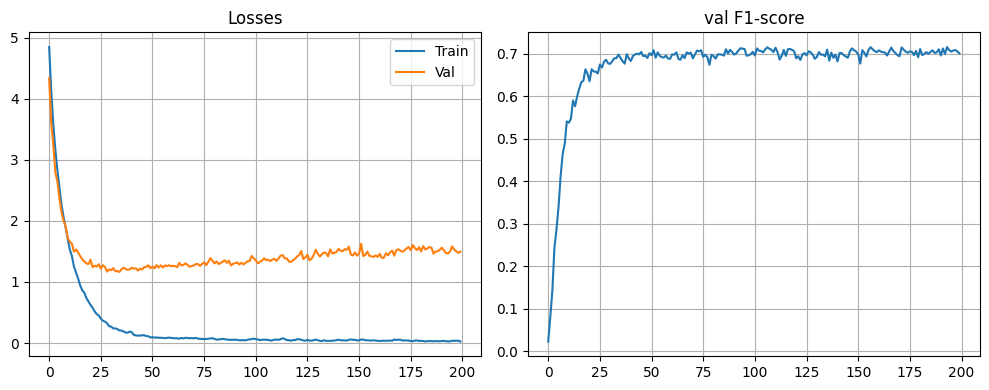

100%|██████████| 200/200 [07:34<00:00,  2.27s/it]

Best score: 0.7162372730157119


PockemonModel(
  (conv_net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): MaxPool2d(kernel

In [20]:
model = ic(PockemonModel(
    img_shape=IN_SHAPE,
    in_ch=3,
    hidden_ch=[32, 64, 128, 256],
    hidden_fc=[],
    out_dim=150,
    conv_dropout=0.1
))

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_loop(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    model_name="best_model_003.pth",
    num_epoches=200
)


ic| torchvision.models.resnet18(): ResNet(
                                     (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
                                     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                                     (relu): ReLU(inplace=True)
                                     (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
                                     (layer1): Sequential(
                                       (0): BasicBlock(
                                         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                                         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                                         (relu): ReLU(inplace=True)
                                         (conv2): Conv2d(64, 64, kernel_size=(3, 3),

  1%|          | 1/100 [00:01<03:05,  1.87s/it]

!!! NEW BEST MODEL !!!
Epoch 0: train_loss 4.549552292659365, val_loss 5.584095257979173, val_f1 0.015336025860340871


  2%|▏         | 2/100 [00:03<03:00,  1.85s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 3.690073317494886, val_loss 3.6372813078073354, val_f1 0.0810492879169745


  3%|▎         | 3/100 [00:05<02:56,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 2: train_loss 3.2623446645407843, val_loss 3.605895079099215, val_f1 0.09550675318571623


  4%|▍         | 4/100 [00:07<02:56,  1.84s/it]

!!! NEW BEST MODEL !!!
Epoch 3: train_loss 2.9497343753946237, val_loss 2.9743105998406043, val_f1 0.2064312851838418


  5%|▌         | 5/100 [00:09<02:52,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 4: train_loss 2.5975762975626977, val_loss 3.010184929921077, val_f1 0.21243078878983385


  6%|▌         | 6/100 [00:10<02:50,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 5: train_loss 2.3713395513337234, val_loss 2.851753675020658, val_f1 0.2543076560765087


  7%|▋         | 7/100 [00:12<02:47,  1.81s/it]

!!! NEW BEST MODEL !!!
Epoch 6: train_loss 2.1393202789898575, val_loss 2.408507328767043, val_f1 0.31142814256824114


  8%|▊         | 8/100 [00:14<02:47,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 7: train_loss 1.881842987290744, val_loss 2.354193870837872, val_f1 0.35560778232720613


  9%|▉         | 9/100 [00:16<02:45,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 8: train_loss 1.7087047839986866, val_loss 2.109191417694092, val_f1 0.41745837698885085


 10%|█         | 10/100 [00:18<02:43,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 9: train_loss 1.4904206456809208, val_loss 2.1736028286126943, val_f1 0.42550718335719284
!!! NEW BEST MODEL !!!
Epoch 10: train_loss 1.2532354881023537, val_loss 2.013973456162673, val_f1 0.47322767927745457


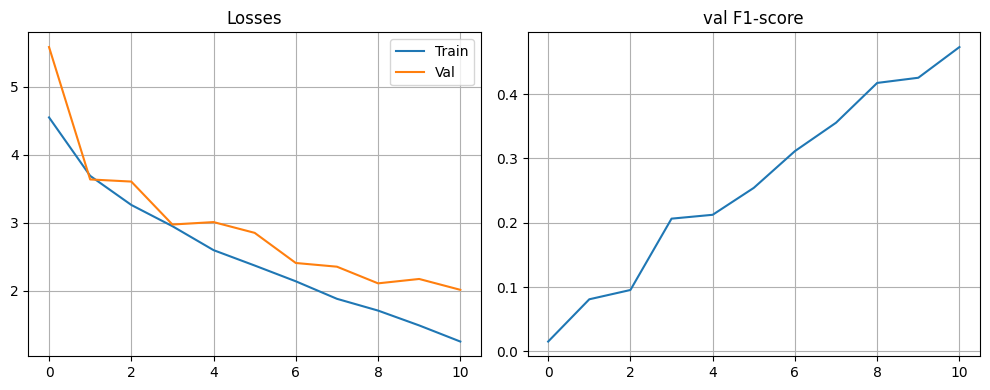

 12%|█▏        | 12/100 [00:21<02:41,  1.84s/it]

!!! NEW BEST MODEL !!!
Epoch 11: train_loss 1.1388258892914345, val_loss 1.7570606011610765, val_f1 0.5232061859759412


 13%|█▎        | 13/100 [00:23<02:38,  1.82s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 0.9885122858244797, val_loss 1.8069537511238685, val_f1 0.5363829561624346


 14%|█▍        | 14/100 [00:25<02:35,  1.81s/it]

Epoch 13: train_loss 0.858521253898226, val_loss 1.919991603264442, val_f1 0.5039911356894673


 15%|█▌        | 15/100 [00:27<02:30,  1.78s/it]

Epoch 14: train_loss 0.74061636883637, val_loss 1.8729943128732534, val_f1 0.5078193418504856


 16%|█▌        | 16/100 [00:28<02:27,  1.75s/it]

Epoch 15: train_loss 0.6589061473977977, val_loss 1.8055944992945745, val_f1 0.5251105045131959


 17%|█▋        | 17/100 [00:30<02:26,  1.77s/it]

!!! NEW BEST MODEL !!!
Epoch 16: train_loss 0.5446766769063884, val_loss 1.7728239114467914, val_f1 0.5479943539167813


 18%|█▊        | 18/100 [00:32<02:25,  1.78s/it]

!!! NEW BEST MODEL !!!
Epoch 17: train_loss 0.4954268017719532, val_loss 1.6645590525407057, val_f1 0.5593422766943916


 19%|█▉        | 19/100 [00:34<02:24,  1.78s/it]

!!! NEW BEST MODEL !!!
Epoch 18: train_loss 0.4185681867188421, val_loss 1.5364927420249352, val_f1 0.6080100192232951


 20%|██        | 20/100 [00:36<02:23,  1.79s/it]

!!! NEW BEST MODEL !!!
Epoch 19: train_loss 0.3410065323114395, val_loss 1.5192235524837787, val_f1 0.6166308705005391
Epoch 20: train_loss 0.30758684154214533, val_loss 1.816656626187838, val_f1 0.5590951001901981


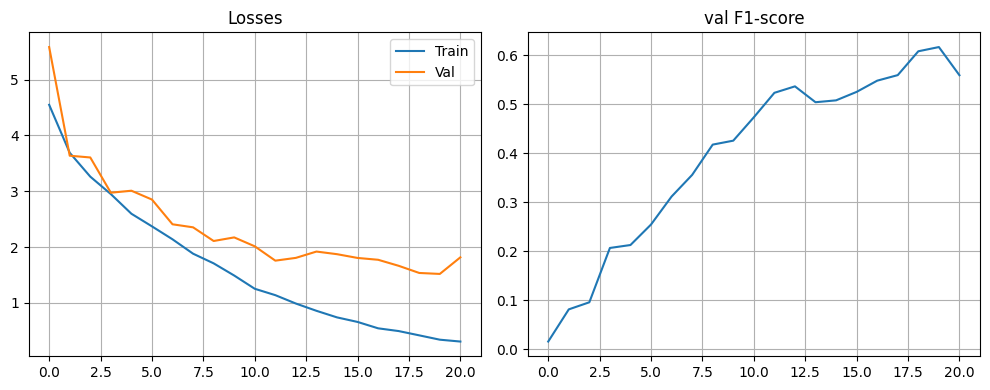

 22%|██▏       | 22/100 [00:39<02:19,  1.78s/it]

Epoch 21: train_loss 0.27459758211826457, val_loss 1.5678870586248546, val_f1 0.616047709550363


 23%|██▎       | 23/100 [00:41<02:17,  1.78s/it]

!!! NEW BEST MODEL !!!
Epoch 22: train_loss 0.24342683574249005, val_loss 1.6327110070448656, val_f1 0.6202031858383809


 24%|██▍       | 24/100 [00:43<02:13,  1.76s/it]

Epoch 23: train_loss 0.20084795972396588, val_loss 1.6188771174504206, val_f1 0.6108761784026125


 25%|██▌       | 25/100 [00:44<02:12,  1.76s/it]

!!! NEW BEST MODEL !!!
Epoch 24: train_loss 0.2028170926817532, val_loss 1.585086547411405, val_f1 0.6281103316279575


 26%|██▌       | 26/100 [00:46<02:09,  1.74s/it]

Epoch 25: train_loss 0.16952989584413067, val_loss 1.633876818877, val_f1 0.5975071857576356


 27%|██▋       | 27/100 [00:48<02:06,  1.73s/it]

Epoch 26: train_loss 0.15372029075334812, val_loss 1.6432613867979784, val_f1 0.6046098353207336


 28%|██▊       | 28/100 [00:50<02:05,  1.74s/it]

!!! NEW BEST MODEL !!!
Epoch 27: train_loss 0.14064518644891935, val_loss 1.5862646928200355, val_f1 0.631762900101878


 29%|██▉       | 29/100 [00:51<02:03,  1.74s/it]

Epoch 28: train_loss 0.11847376746350322, val_loss 1.6308223009109497, val_f1 0.6233435452978688


 30%|███       | 30/100 [00:53<02:02,  1.75s/it]

Epoch 29: train_loss 0.11369802995488562, val_loss 1.6120877357629628, val_f1 0.6224929751423556
Epoch 30: train_loss 0.11419730941797125, val_loss 1.5609944416926458, val_f1 0.6305951879814862


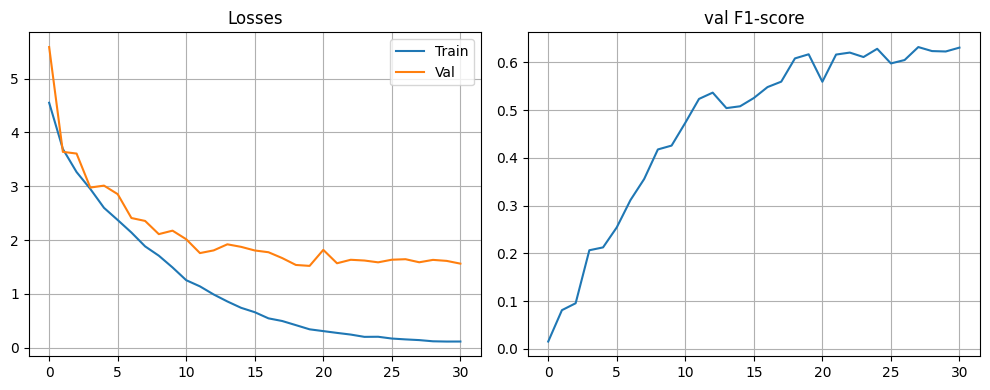

 32%|███▏      | 32/100 [00:57<02:00,  1.78s/it]

!!! NEW BEST MODEL !!!
Epoch 31: train_loss 0.09575355836543543, val_loss 1.618227876149691, val_f1 0.6391777714422329


 33%|███▎      | 33/100 [00:59<01:59,  1.79s/it]

!!! NEW BEST MODEL !!!
Epoch 32: train_loss 0.10081235486371763, val_loss 1.6608662513586192, val_f1 0.6400431789398169


 34%|███▍      | 34/100 [01:00<01:58,  1.79s/it]

!!! NEW BEST MODEL !!!
Epoch 33: train_loss 0.09940229677434625, val_loss 1.595288139123183, val_f1 0.647120340846729


 35%|███▌      | 35/100 [01:02<01:56,  1.79s/it]

!!! NEW BEST MODEL !!!
Epoch 34: train_loss 0.08821857476542735, val_loss 1.5064702675892756, val_f1 0.6595999288786846


 36%|███▌      | 36/100 [01:04<01:53,  1.77s/it]

Epoch 35: train_loss 0.05941419335531777, val_loss 1.5421222906846266, val_f1 0.6412073538632947


 37%|███▋      | 37/100 [01:06<01:50,  1.75s/it]

Epoch 36: train_loss 0.04881353278098435, val_loss 1.5482536187538734, val_f1 0.6554959046353739


 38%|███▊      | 38/100 [01:07<01:48,  1.74s/it]

Epoch 37: train_loss 0.05436165418861241, val_loss 1.5764259833555956, val_f1 0.6488034909329545


 39%|███▉      | 39/100 [01:09<01:45,  1.73s/it]

Epoch 38: train_loss 0.05077657386146743, val_loss 1.5459190240273109, val_f1 0.6541644718794152


 40%|████      | 40/100 [01:11<01:45,  1.75s/it]

!!! NEW BEST MODEL !!!
Epoch 39: train_loss 0.05407912939273078, val_loss 1.514418519460238, val_f1 0.6668239476980322
Epoch 40: train_loss 0.06750595916447968, val_loss 1.8669089537400465, val_f1 0.6162929599299052


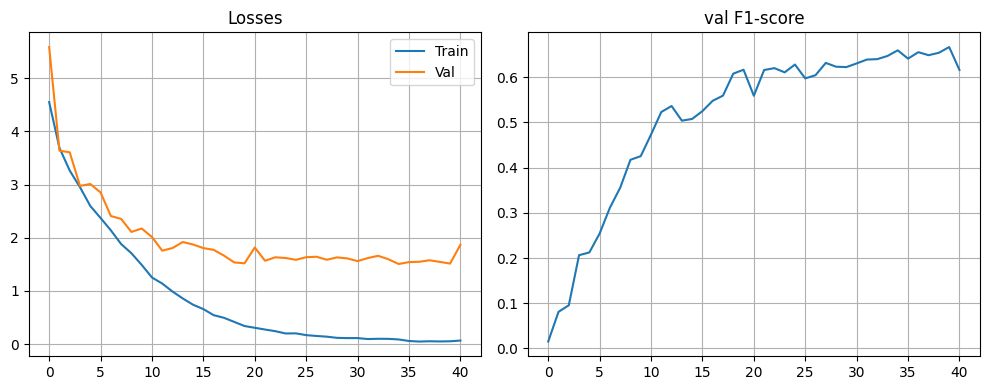

 42%|████▏     | 42/100 [01:14<01:41,  1.75s/it]

Epoch 41: train_loss 0.07176874244007571, val_loss 1.774612729366009, val_f1 0.6279125917174573


 43%|████▎     | 43/100 [01:16<01:38,  1.73s/it]

Epoch 42: train_loss 0.06154342458165925, val_loss 1.756573273585393, val_f1 0.6269163364848287


 44%|████▍     | 44/100 [01:18<01:37,  1.74s/it]

Epoch 43: train_loss 0.06997411556798837, val_loss 1.7740443211335402, val_f1 0.6255134552535779


 45%|████▌     | 45/100 [01:19<01:34,  1.73s/it]

Epoch 44: train_loss 0.08103046232256396, val_loss 1.8192033492601836, val_f1 0.6256021187160038


 46%|████▌     | 46/100 [01:21<01:32,  1.72s/it]

Epoch 45: train_loss 0.07825577535249036, val_loss 1.7219658906643207, val_f1 0.6350790720551316


 47%|████▋     | 47/100 [01:23<01:30,  1.71s/it]

Epoch 46: train_loss 0.09890606549793277, val_loss 1.8476454294644868, val_f1 0.608126637359967


 48%|████▊     | 48/100 [01:25<01:29,  1.71s/it]

Epoch 47: train_loss 0.12854644270806476, val_loss 1.9597110014695387, val_f1 0.592112054159708


 49%|████▉     | 49/100 [01:26<01:27,  1.72s/it]

Epoch 48: train_loss 0.10063880386537519, val_loss 2.122909527558547, val_f1 0.5704598192270044


 50%|█████     | 50/100 [01:28<01:25,  1.72s/it]

Epoch 49: train_loss 0.0693566083008873, val_loss 1.670373329749474, val_f1 0.6427688025909849
Epoch 50: train_loss 0.05010282164760705, val_loss 1.650717542721675, val_f1 0.6580144094958706


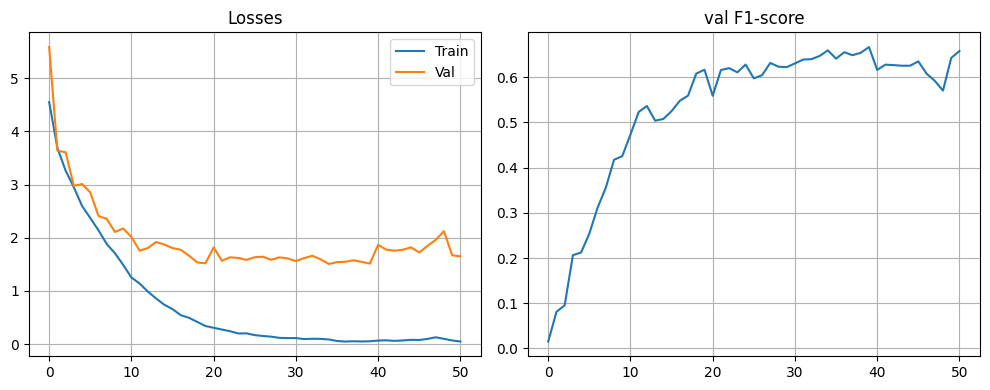

 52%|█████▏    | 52/100 [01:32<01:22,  1.72s/it]

Epoch 51: train_loss 0.058455355433297565, val_loss 1.7072926301222582, val_f1 0.6408604603782692


 53%|█████▎    | 53/100 [01:33<01:20,  1.71s/it]

Epoch 52: train_loss 0.053311795638553025, val_loss 1.633029002409715, val_f1 0.658576881461627


 54%|█████▍    | 54/100 [01:35<01:19,  1.72s/it]

Epoch 53: train_loss 0.04382366372336601, val_loss 1.7055605283150306, val_f1 0.6398949171668838


 55%|█████▌    | 55/100 [01:37<01:17,  1.72s/it]

Epoch 54: train_loss 0.0376771556149269, val_loss 1.684136757483849, val_f1 0.6467369169972773


 56%|█████▌    | 56/100 [01:38<01:15,  1.71s/it]

Epoch 55: train_loss 0.02770525820810219, val_loss 1.6336068373460035, val_f1 0.6582189521234099


 57%|█████▋    | 57/100 [01:40<01:13,  1.70s/it]

Epoch 56: train_loss 0.028930853570586647, val_loss 1.6371953120598426, val_f1 0.6554025176080333


 58%|█████▊    | 58/100 [01:42<01:11,  1.70s/it]

Epoch 57: train_loss 0.028663045469799947, val_loss 1.561794455234821, val_f1 0.6629073879514228


 59%|█████▉    | 59/100 [01:43<01:10,  1.72s/it]

!!! NEW BEST MODEL !!!
Epoch 58: train_loss 0.02629752100670132, val_loss 1.5002668454096868, val_f1 0.6832967298300433


 60%|██████    | 60/100 [01:45<01:08,  1.72s/it]

Epoch 59: train_loss 0.022745397246988684, val_loss 1.6251076184786284, val_f1 0.6657580623646705
Epoch 60: train_loss 0.024230140614612348, val_loss 1.7179482716780443, val_f1 0.6493432356129791


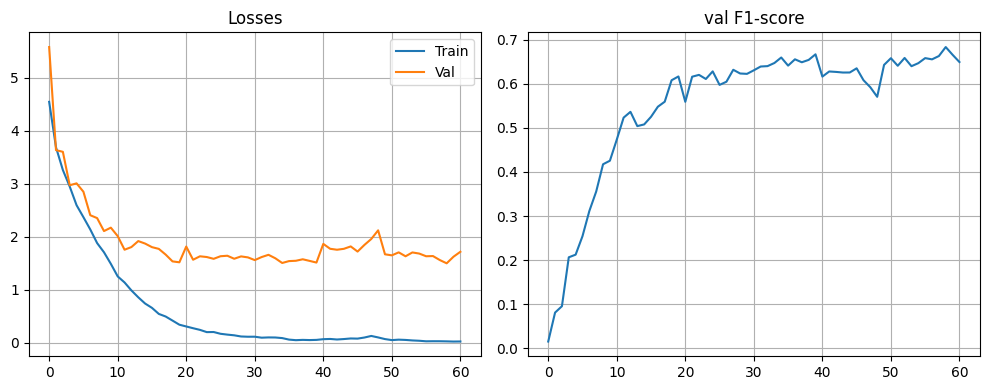

 62%|██████▏   | 62/100 [01:49<01:05,  1.74s/it]

Epoch 61: train_loss 0.03747861524080408, val_loss 1.8736992615919847, val_f1 0.6442433472537077


 63%|██████▎   | 63/100 [01:50<01:03,  1.73s/it]

Epoch 62: train_loss 0.0652511627895051, val_loss 1.9370492605062632, val_f1 0.614188828557099


 64%|██████▍   | 64/100 [01:52<01:01,  1.72s/it]

Epoch 63: train_loss 0.07263238214213273, val_loss 1.981838923234206, val_f1 0.6129018461333167


 65%|██████▌   | 65/100 [01:54<00:59,  1.71s/it]

Epoch 64: train_loss 0.0618333935352235, val_loss 1.7686405181884766, val_f1 0.6386751402190263


 66%|██████▌   | 66/100 [01:56<00:58,  1.73s/it]

Epoch 65: train_loss 0.05869825678909647, val_loss 1.8006527698957002, val_f1 0.6282760994604081


 67%|██████▋   | 67/100 [01:57<00:56,  1.72s/it]

Epoch 66: train_loss 0.052124989315353594, val_loss 1.7525663009056678, val_f1 0.640908089990253


 68%|██████▊   | 68/100 [01:59<00:55,  1.72s/it]

Epoch 67: train_loss 0.04875266083098691, val_loss 1.7740111717810998, val_f1 0.6365679655166794


 69%|██████▉   | 69/100 [02:01<00:53,  1.72s/it]

Epoch 68: train_loss 0.042496839409758305, val_loss 1.734474778175354, val_f1 0.648591348342523


 70%|███████   | 70/100 [02:02<00:51,  1.72s/it]

Epoch 69: train_loss 0.048199172934581494, val_loss 1.716792345046997, val_f1 0.6528510676745679
Epoch 70: train_loss 0.04990816938466039, val_loss 1.736410223520719, val_f1 0.6566524839678183


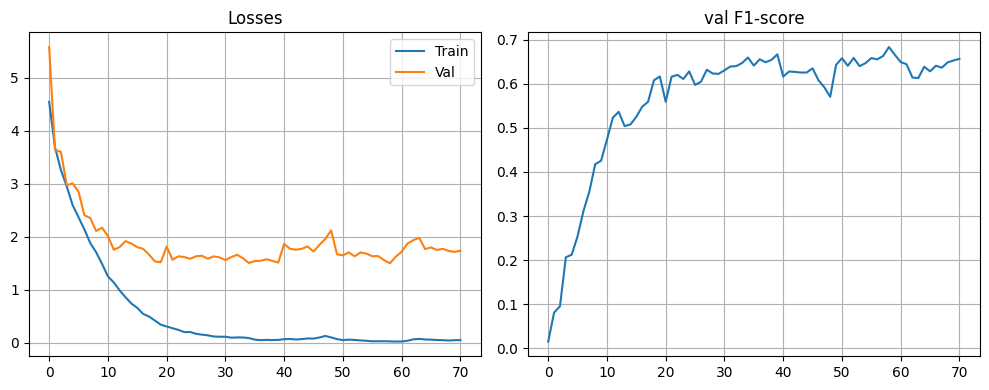

 72%|███████▏  | 72/100 [02:06<00:48,  1.74s/it]

Epoch 71: train_loss 0.06301078084727814, val_loss 2.026110575749324, val_f1 0.602866514649062


 73%|███████▎  | 73/100 [02:08<00:46,  1.73s/it]

Epoch 72: train_loss 0.06548463951410918, val_loss 1.8389140275808482, val_f1 0.6395026802854901


 74%|███████▍  | 74/100 [02:09<00:44,  1.72s/it]

Epoch 73: train_loss 0.06519595328076132, val_loss 1.8341483886425312, val_f1 0.6449539466958056


 75%|███████▌  | 75/100 [02:11<00:42,  1.71s/it]

Epoch 74: train_loss 0.068784785039466, val_loss 2.087540085499103, val_f1 0.6090402448479555


 76%|███████▌  | 76/100 [02:13<00:40,  1.71s/it]

Epoch 75: train_loss 0.09630868866525848, val_loss 1.936977560703571, val_f1 0.6250207841968849


 77%|███████▋  | 77/100 [02:14<00:39,  1.70s/it]

Epoch 76: train_loss 0.07581322286920301, val_loss 2.016441528613751, val_f1 0.6198663260210218


 78%|███████▊  | 78/100 [02:16<00:37,  1.70s/it]

Epoch 77: train_loss 0.07903815793066189, val_loss 1.9273282381204457, val_f1 0.6374961980783961


 79%|███████▉  | 79/100 [02:18<00:35,  1.70s/it]

Epoch 78: train_loss 0.0739136016445941, val_loss 2.1172505158644457, val_f1 0.6111075058459451


 80%|████████  | 80/100 [02:20<00:34,  1.70s/it]

Epoch 79: train_loss 0.07430009402591607, val_loss 1.96159604879526, val_f1 0.6147527163889474
Epoch 80: train_loss 0.0630283881107281, val_loss 2.091460099587074, val_f1 0.6098934017162669


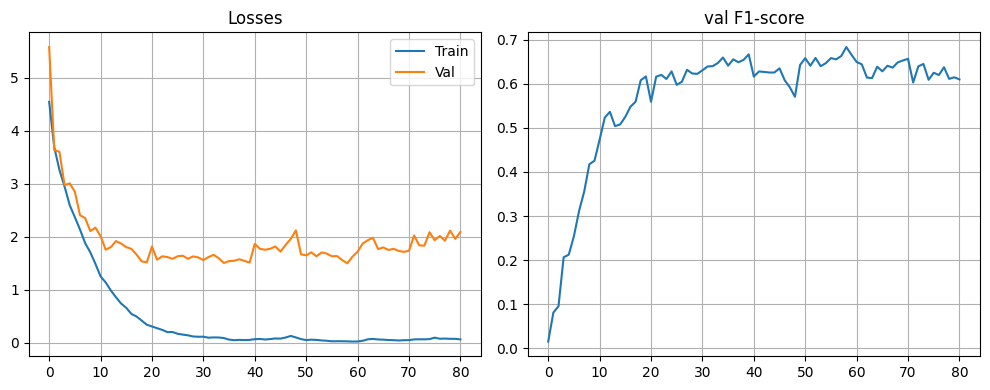

 82%|████████▏ | 82/100 [02:23<00:31,  1.75s/it]

Epoch 81: train_loss 0.048783710611791445, val_loss 1.8658236723679762, val_f1 0.6369173491115286


 83%|████████▎ | 83/100 [02:25<00:29,  1.73s/it]

Epoch 82: train_loss 0.0348421078946056, val_loss 1.7717946401009192, val_f1 0.6534838051906153


 84%|████████▍ | 84/100 [02:27<00:28,  1.76s/it]

Epoch 83: train_loss 0.029934229361342973, val_loss 1.7867815769635713, val_f1 0.656346083170557


 85%|████████▌ | 85/100 [02:28<00:26,  1.74s/it]

Epoch 84: train_loss 0.022157575003802776, val_loss 1.7164377982799823, val_f1 0.6740132844374369


 86%|████████▌ | 86/100 [02:30<00:24,  1.73s/it]

Epoch 85: train_loss 0.021633988166035248, val_loss 1.687352519768935, val_f1 0.6605833790382482


 87%|████████▋ | 87/100 [02:32<00:22,  1.72s/it]

Epoch 86: train_loss 0.022097708151579416, val_loss 1.6715065974455614, val_f1 0.6825115562658257


 88%|████████▊ | 88/100 [02:34<00:20,  1.72s/it]

Epoch 87: train_loss 0.021017537018733806, val_loss 1.7512115698594313, val_f1 0.6697039963561932


 89%|████████▉ | 89/100 [02:35<00:18,  1.71s/it]

Epoch 88: train_loss 0.03429328419011215, val_loss 1.7925599538362944, val_f1 0.654760662159564


 90%|█████████ | 90/100 [02:37<00:17,  1.71s/it]

Epoch 89: train_loss 0.03962620155050837, val_loss 1.8162043736531184, val_f1 0.6635947283291079
Epoch 90: train_loss 0.03528252900738654, val_loss 1.8424133520859938, val_f1 0.6498657895232239


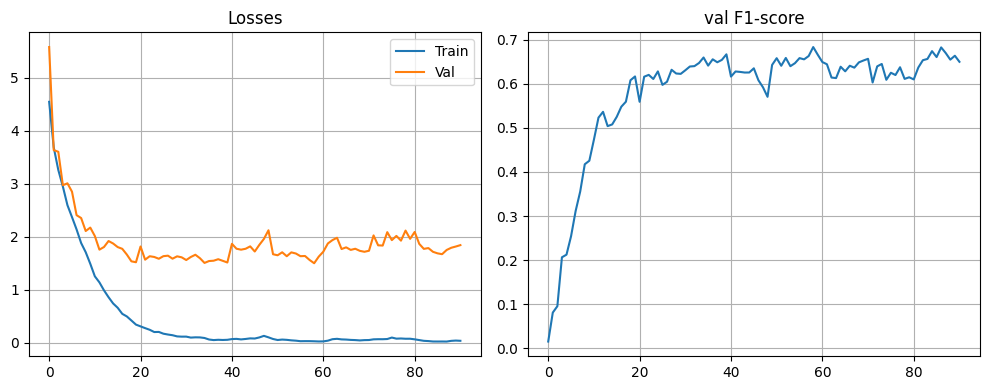

 92%|█████████▏| 92/100 [02:40<00:13,  1.73s/it]

Epoch 91: train_loss 0.03660602267060814, val_loss 1.7902688796703632, val_f1 0.6450267534627414


 93%|█████████▎| 93/100 [02:42<00:12,  1.72s/it]

Epoch 92: train_loss 0.023149023474804287, val_loss 1.7678261628517737, val_f1 0.6732875291143914


 94%|█████████▍| 94/100 [02:44<00:10,  1.72s/it]

Epoch 93: train_loss 0.01891453699048223, val_loss 1.6801648690150335, val_f1 0.6773869348994858


 95%|█████████▌| 95/100 [02:46<00:08,  1.71s/it]

Epoch 94: train_loss 0.026741952683519702, val_loss 1.9580656106655414, val_f1 0.6439071918457654


 96%|█████████▌| 96/100 [02:47<00:06,  1.72s/it]

Epoch 95: train_loss 0.027143975061460816, val_loss 1.8381322530599742, val_f1 0.6643654623397913


 97%|█████████▋| 97/100 [02:49<00:05,  1.71s/it]

Epoch 96: train_loss 0.027844701476138215, val_loss 1.7773905992507935, val_f1 0.6722817530003941


 98%|█████████▊| 98/100 [02:51<00:03,  1.71s/it]

Epoch 97: train_loss 0.023481733807972794, val_loss 1.7131410653774555, val_f1 0.6754801481494597


 99%|█████████▉| 99/100 [02:52<00:01,  1.70s/it]

Epoch 98: train_loss 0.035779519375927486, val_loss 1.8695106506347656, val_f1 0.6527763100362864
Epoch 99: train_loss 0.03764921410715785, val_loss 1.878590125304002, val_f1 0.662937134303764


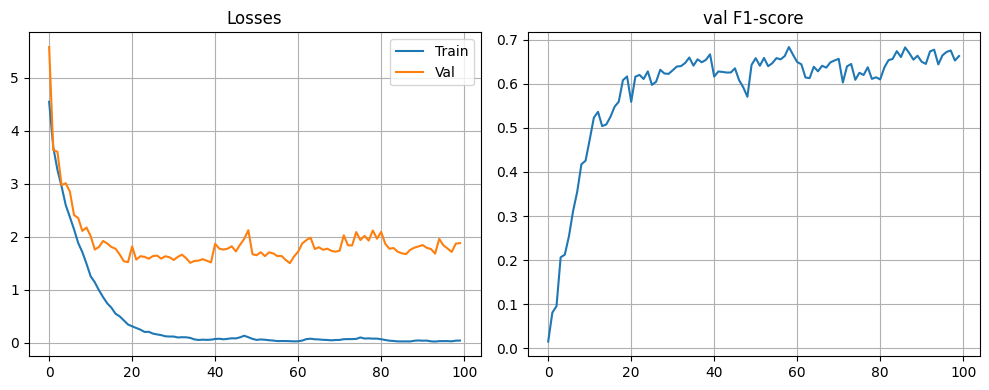

100%|██████████| 100/100 [02:54<00:00,  1.75s/it]

Best score: 0.6832967298300433


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [31]:
model = ic(torchvision.models.resnet18())
model.fc = nn.Linear(512, 150)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_loop(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    model_name="best_model_002.pth"
)


ic| torchvision.models.mobilenet_v3_small(): MobileNetV3(
                                               (features): Sequential(
                                                 (0): Conv2dNormActivation(
                                                   (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
                                                   (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
                                                   (2): Hardswish()
                                                 )
                                                 (1): InvertedResidual(
                                                   (block): Sequential(
                                                     (0): Conv2dNormActivation(
                                                       (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
                                 

!!! NEW BEST MODEL !!!
Epoch 0: train_loss 5.617267970381112, val_loss 5.909138899583083, val_f1 8.422825858075385e-05


  2%|▏         | 2/100 [00:03<02:41,  1.64s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 4.631651565946382, val_loss 5.5607715386610765, val_f1 0.00012594458438287156


  3%|▎         | 3/100 [00:04<02:31,  1.56s/it]

Epoch 2: train_loss 4.213169262326997, val_loss 5.363343092111441, val_f1 9.259259259259259e-05


  4%|▍         | 4/100 [00:06<02:26,  1.53s/it]

Epoch 3: train_loss 3.861601582888899, val_loss 5.327234818385198, val_f1 0.00012594458438287156


  5%|▌         | 5/100 [00:07<02:23,  1.52s/it]

Epoch 4: train_loss 3.5630292645816146, val_loss 5.39001805965717, val_f1 0.00012594458438287156


  6%|▌         | 6/100 [00:09<02:21,  1.51s/it]

Epoch 5: train_loss 3.3230948777034364, val_loss 5.449310559492845, val_f1 0.00012594458438287156


  7%|▋         | 7/100 [00:10<02:20,  1.51s/it]

Epoch 6: train_loss 3.0226081650832604, val_loss 5.5639352064866285, val_f1 0.00012594458438287156


  8%|▊         | 8/100 [00:12<02:19,  1.52s/it]

Epoch 7: train_loss 2.8046775110836686, val_loss 5.626085097973164, val_f1 0.00012594458438287156


  9%|▉         | 9/100 [00:13<02:17,  1.51s/it]

Epoch 8: train_loss 2.645722907165001, val_loss 5.859653179462139, val_f1 0.00012594458438287156


 10%|█         | 10/100 [00:15<02:15,  1.51s/it]

Epoch 9: train_loss 2.485896817569075, val_loss 6.044971502744234, val_f1 6.746784735399536e-05
Epoch 10: train_loss 2.2983503670528016, val_loss 6.334356344663179, val_f1 6.746784735399536e-05


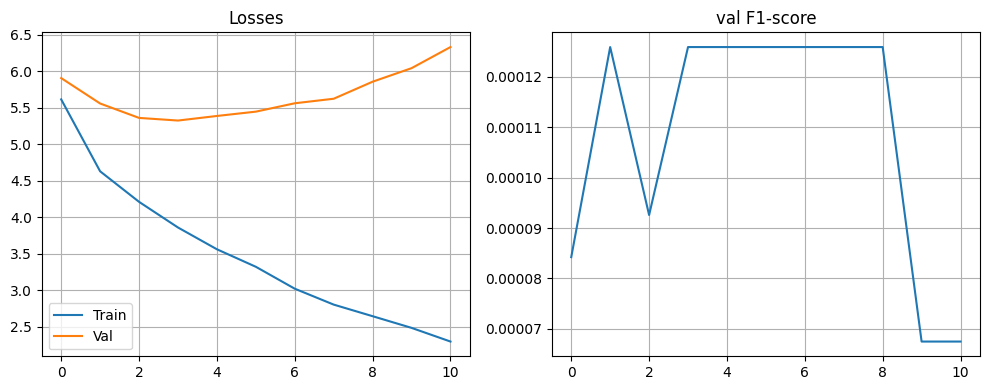

 12%|█▏        | 12/100 [00:18<02:15,  1.54s/it]

Epoch 11: train_loss 2.1224740414783874, val_loss 6.210457214942346, val_f1 6.746784735399536e-05


 13%|█▎        | 13/100 [00:19<02:12,  1.53s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 2.049254635284687, val_loss 6.426433233114389, val_f1 0.0005965080977371481


 14%|█▍        | 14/100 [00:21<02:10,  1.51s/it]

Epoch 13: train_loss 1.9044043730045188, val_loss 6.574211377363938, val_f1 0.0004889571731404313


 15%|█▌        | 15/100 [00:22<02:08,  1.51s/it]

!!! NEW BEST MODEL !!!
Epoch 14: train_loss 1.8100105770703019, val_loss 6.2259872509883, val_f1 0.006431338741887675


 16%|█▌        | 16/100 [00:24<02:08,  1.53s/it]

!!! NEW BEST MODEL !!!
Epoch 15: train_loss 1.6665183757913524, val_loss 5.44664768072275, val_f1 0.01556243761006412


 17%|█▋        | 17/100 [00:25<02:05,  1.52s/it]

!!! NEW BEST MODEL !!!
Epoch 16: train_loss 1.599607200458132, val_loss 4.740015396705041, val_f1 0.06575306292198099


 18%|█▊        | 18/100 [00:27<02:04,  1.52s/it]

!!! NEW BEST MODEL !!!
Epoch 17: train_loss 1.4759270569373821, val_loss 3.8379300190852237, val_f1 0.17661550520900166


 19%|█▉        | 19/100 [00:29<02:02,  1.51s/it]

!!! NEW BEST MODEL !!!
Epoch 18: train_loss 1.3498558957001259, val_loss 3.029738426208496, val_f1 0.2789504901057195


 20%|██        | 20/100 [00:30<02:00,  1.50s/it]

!!! NEW BEST MODEL !!!
Epoch 19: train_loss 1.2866706354864712, val_loss 2.257830317203815, val_f1 0.4372196733618343
Epoch 20: train_loss 1.2529997620089302, val_loss 2.4801808503957896, val_f1 0.40829753303330674


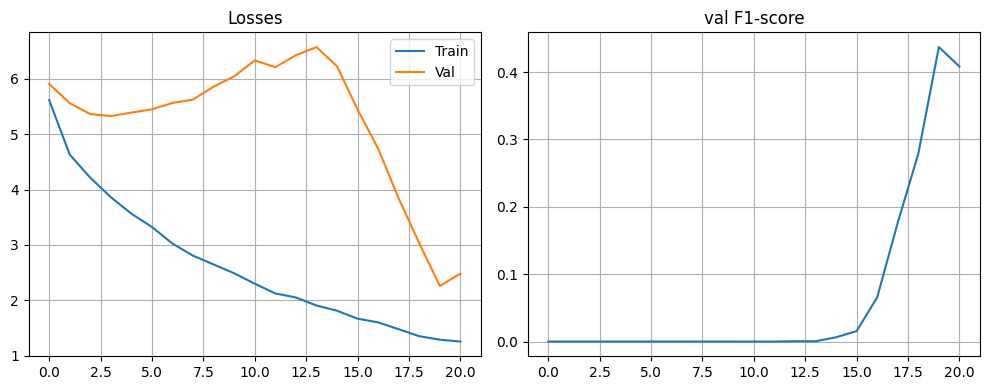

 22%|██▏       | 22/100 [00:33<01:59,  1.53s/it]

!!! NEW BEST MODEL !!!
Epoch 21: train_loss 1.1373175094867576, val_loss 2.3555927826808047, val_f1 0.44454120444292017


 23%|██▎       | 23/100 [00:35<01:57,  1.52s/it]

Epoch 22: train_loss 1.077261053282639, val_loss 2.4211756816277137, val_f1 0.432811851148422


 24%|██▍       | 24/100 [00:36<01:55,  1.52s/it]

Epoch 23: train_loss 1.0294157492703404, val_loss 2.643287181854248, val_f1 0.4096724046194438


 25%|██▌       | 25/100 [00:38<01:53,  1.51s/it]

Epoch 24: train_loss 0.9542338848114014, val_loss 2.4853407603043776, val_f1 0.4415610342345146


 26%|██▌       | 26/100 [00:39<01:52,  1.52s/it]

Epoch 25: train_loss 0.8987897552292923, val_loss 3.119563872997577, val_f1 0.3760293859968988


 27%|██▋       | 27/100 [00:41<01:50,  1.51s/it]

Epoch 26: train_loss 0.8280579365532974, val_loss 2.8966494706960826, val_f1 0.41459978722248414


 28%|██▊       | 28/100 [00:42<01:48,  1.50s/it]

Epoch 27: train_loss 0.8547626034966831, val_loss 2.8707890693957987, val_f1 0.4055558841302182


 29%|██▉       | 29/100 [00:44<01:46,  1.50s/it]

Epoch 28: train_loss 0.7693588158179974, val_loss 2.804258401577289, val_f1 0.42438801245006497


 30%|███       | 30/100 [00:45<01:44,  1.49s/it]

Epoch 29: train_loss 0.7044844175207203, val_loss 2.8873477899111233, val_f1 0.42433209800555516
!!! NEW BEST MODEL !!!
Epoch 30: train_loss 0.6234888136386871, val_loss 2.6100686330061693, val_f1 0.4609674606293472


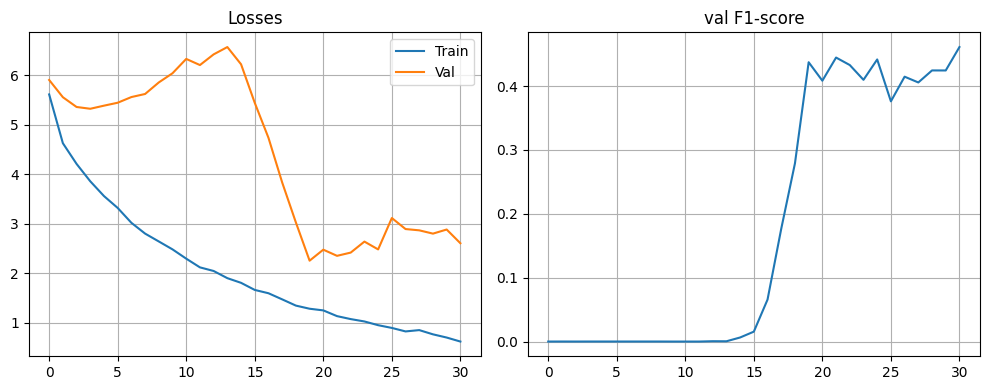

 32%|███▏      | 32/100 [00:48<01:44,  1.53s/it]

Epoch 31: train_loss 0.6408378461311603, val_loss 2.7776931982774, val_f1 0.44716826785621466


 33%|███▎      | 33/100 [00:50<01:42,  1.53s/it]

Epoch 32: train_loss 0.561695645595419, val_loss 2.8438961689288798, val_f1 0.4579027373297428


 34%|███▍      | 34/100 [00:51<01:40,  1.53s/it]

Epoch 33: train_loss 0.5844716522200354, val_loss 2.833557055546687, val_f1 0.4471056738210682


 35%|███▌      | 35/100 [00:53<01:38,  1.51s/it]

Epoch 34: train_loss 0.5671984409463817, val_loss 2.838418795512273, val_f1 0.4482126144808821


 36%|███▌      | 36/100 [00:54<01:36,  1.51s/it]

Epoch 35: train_loss 0.5269846320152283, val_loss 2.929941544165978, val_f1 0.44114517453892915


 37%|███▋      | 37/100 [00:56<01:34,  1.51s/it]

!!! NEW BEST MODEL !!!
Epoch 36: train_loss 0.44713827916260424, val_loss 2.5996882640398464, val_f1 0.4992166521438589


 38%|███▊      | 38/100 [00:57<01:33,  1.50s/it]

Epoch 37: train_loss 0.45492198446701315, val_loss 2.766590796984159, val_f1 0.48375504667390035


 39%|███▉      | 39/100 [00:59<01:31,  1.50s/it]

Epoch 38: train_loss 0.42504697318734797, val_loss 2.899258907024677, val_f1 0.4835370511429298


 40%|████      | 40/100 [01:00<01:30,  1.50s/it]

Epoch 39: train_loss 0.4262655819284505, val_loss 2.9403165670541616, val_f1 0.4733002623352828
Epoch 40: train_loss 0.4438215473602558, val_loss 2.8533689425541806, val_f1 0.4854455577878063


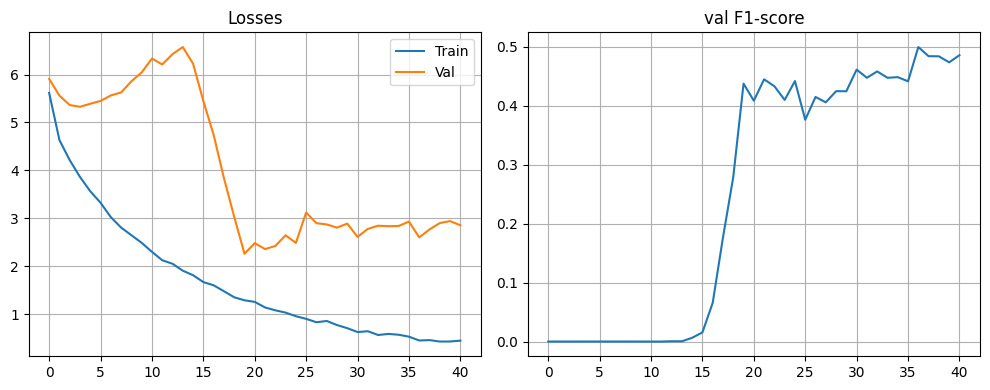

 42%|████▏     | 42/100 [01:03<01:27,  1.52s/it]

Epoch 41: train_loss 0.38615946368924503, val_loss 2.680859529055082, val_f1 0.4974898027488634


 43%|████▎     | 43/100 [01:05<01:25,  1.51s/it]

Epoch 42: train_loss 0.3566159441553313, val_loss 2.8150707941788893, val_f1 0.4914086280582319


 44%|████▍     | 44/100 [01:06<01:25,  1.52s/it]

Epoch 43: train_loss 0.32470243758168715, val_loss 2.7380774387946496, val_f1 0.4829133834701228


 45%|████▌     | 45/100 [01:08<01:23,  1.52s/it]

Epoch 44: train_loss 0.37084230831984816, val_loss 3.056074729332557, val_f1 0.4745595359899092


 46%|████▌     | 46/100 [01:09<01:21,  1.52s/it]

!!! NEW BEST MODEL !!!
Epoch 45: train_loss 0.3248855517856006, val_loss 2.659032399837787, val_f1 0.5134341229209747


 47%|████▋     | 47/100 [01:11<01:20,  1.52s/it]

Epoch 46: train_loss 0.34253667654662295, val_loss 2.8420028686523438, val_f1 0.4892031396430277


 48%|████▊     | 48/100 [01:12<01:19,  1.52s/it]

Epoch 47: train_loss 0.2942968072562382, val_loss 2.729237776536208, val_f1 0.5083884555858135


 49%|████▉     | 49/100 [01:14<01:16,  1.51s/it]

Epoch 48: train_loss 0.2860021174981676, val_loss 2.9070166991307187, val_f1 0.5017948271398529


 50%|█████     | 50/100 [01:15<01:14,  1.50s/it]

!!! NEW BEST MODEL !!!
Epoch 49: train_loss 0.2952152583105811, val_loss 2.7867915630340576, val_f1 0.5161341647223473
Epoch 50: train_loss 0.2852990056934028, val_loss 2.8417018010066104, val_f1 0.5072700722305558


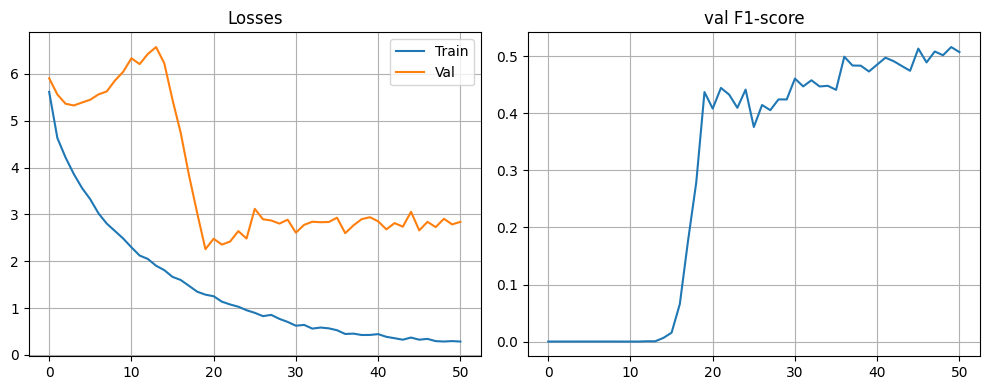

 52%|█████▏    | 52/100 [01:19<01:12,  1.52s/it]

Epoch 51: train_loss 0.28627057270757084, val_loss 2.900908323434683, val_f1 0.5096025063801314


 53%|█████▎    | 53/100 [01:20<01:12,  1.53s/it]

Epoch 52: train_loss 0.27490455785702017, val_loss 3.0935387427990255, val_f1 0.48964448636779956


 54%|█████▍    | 54/100 [01:22<01:09,  1.52s/it]

Epoch 53: train_loss 0.2472888657758976, val_loss 2.751720226727999, val_f1 0.5113065273433954


 55%|█████▌    | 55/100 [01:23<01:07,  1.51s/it]

Epoch 54: train_loss 0.2377706329370367, val_loss 2.824167068188007, val_f1 0.5121482520949824


 56%|█████▌    | 56/100 [01:25<01:06,  1.50s/it]

!!! NEW BEST MODEL !!!
Epoch 55: train_loss 0.23705038633839837, val_loss 2.6747064223656287, val_f1 0.5289986006920883


 57%|█████▋    | 57/100 [01:26<01:05,  1.53s/it]

Epoch 56: train_loss 0.19385311110266323, val_loss 2.679005421124972, val_f1 0.5240245384530072


 58%|█████▊    | 58/100 [01:28<01:04,  1.53s/it]

Epoch 57: train_loss 0.2213529664380797, val_loss 2.802862625855666, val_f1 0.527445124875977


 59%|█████▉    | 59/100 [01:29<01:02,  1.52s/it]

!!! NEW BEST MODEL !!!
Epoch 58: train_loss 0.21364787246646552, val_loss 2.690266884290255, val_f1 0.5382133806075726


 60%|██████    | 60/100 [01:31<01:00,  1.51s/it]

Epoch 59: train_loss 0.18875787201626548, val_loss 2.7384435580326962, val_f1 0.53505258108303
Epoch 60: train_loss 0.21106634802859406, val_loss 3.0393849336183987, val_f1 0.5152110794773384


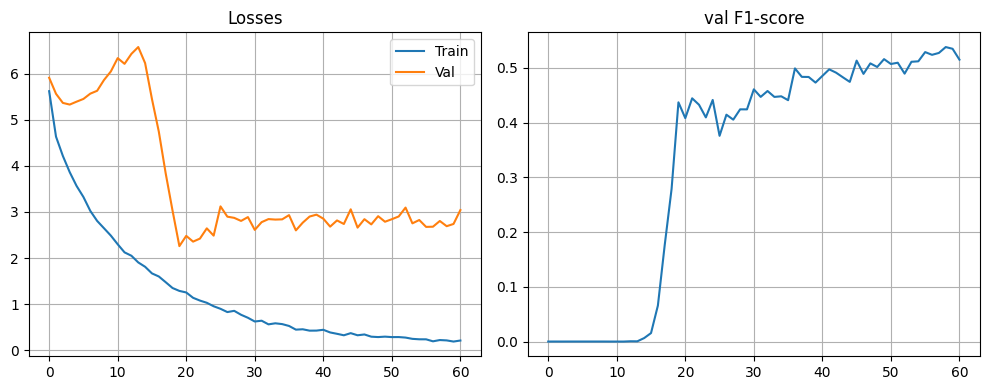

 62%|██████▏   | 62/100 [01:34<00:58,  1.53s/it]

Epoch 61: train_loss 0.22619567349039274, val_loss 2.7508172438694882, val_f1 0.5326754717134417


 63%|██████▎   | 63/100 [01:35<00:56,  1.52s/it]

Epoch 62: train_loss 0.18945250917097617, val_loss 2.930189847946167, val_f1 0.5183874030855944


 64%|██████▍   | 64/100 [01:37<00:54,  1.53s/it]

Epoch 63: train_loss 0.18059462668566867, val_loss 2.8344832200270433, val_f1 0.5272942794988225


 65%|██████▌   | 65/100 [01:38<00:53,  1.52s/it]

Epoch 64: train_loss 0.17681993287185144, val_loss 2.9362275417034445, val_f1 0.5271252495612837


 66%|██████▌   | 66/100 [01:40<00:51,  1.53s/it]

!!! NEW BEST MODEL !!!
Epoch 65: train_loss 0.19380028828464704, val_loss 2.8881788070385275, val_f1 0.5427140348834151


 67%|██████▋   | 67/100 [01:41<00:50,  1.52s/it]

Epoch 66: train_loss 0.1872831973536261, val_loss 2.917052489060622, val_f1 0.5205991569197882


 68%|██████▊   | 68/100 [01:43<00:48,  1.50s/it]

Epoch 67: train_loss 0.16532278330675487, val_loss 2.7694914524371805, val_f1 0.539590658488458


 69%|██████▉   | 69/100 [01:44<00:46,  1.50s/it]

Epoch 68: train_loss 0.1489060292470044, val_loss 2.8576900959014893, val_f1 0.5206319449181734


 70%|███████   | 70/100 [01:46<00:44,  1.49s/it]

Epoch 69: train_loss 0.1894083689769794, val_loss 2.8518432470468373, val_f1 0.5314473395043418
Epoch 70: train_loss 0.18473874315105634, val_loss 2.859911771921011, val_f1 0.5334517913947386


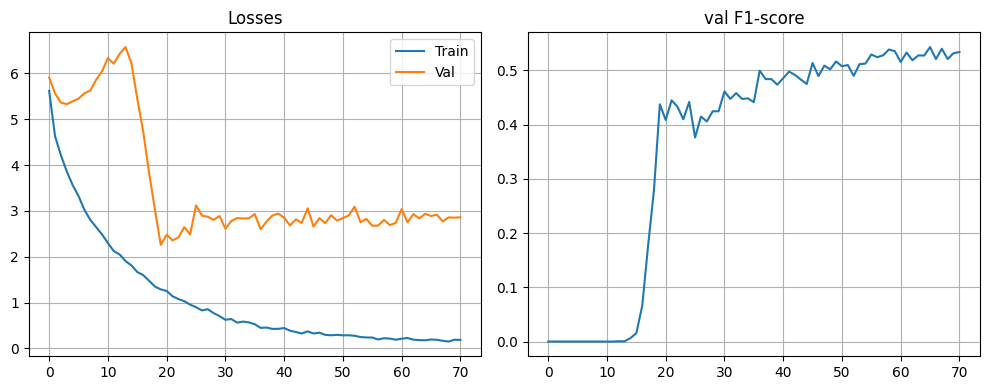

 72%|███████▏  | 72/100 [01:49<00:42,  1.52s/it]

Epoch 71: train_loss 0.18461362323884306, val_loss 2.936929409320538, val_f1 0.5300526733487635


 73%|███████▎  | 73/100 [01:50<00:40,  1.51s/it]

Epoch 72: train_loss 0.16382970147091766, val_loss 2.988081015073336, val_f1 0.5385166827656545


 74%|███████▍  | 74/100 [01:52<00:39,  1.51s/it]

Epoch 73: train_loss 0.140995217037612, val_loss 2.7871885299682617, val_f1 0.535686619724809


 75%|███████▌  | 75/100 [01:53<00:37,  1.51s/it]

!!! NEW BEST MODEL !!!
Epoch 74: train_loss 0.11850089065987489, val_loss 2.8358626549060526, val_f1 0.5621517016059714


 76%|███████▌  | 76/100 [01:55<00:36,  1.51s/it]

Epoch 75: train_loss 0.12468122588149433, val_loss 2.900378887469952, val_f1 0.5512694597097484


 77%|███████▋  | 77/100 [01:56<00:34,  1.51s/it]

Epoch 76: train_loss 0.15038911407363825, val_loss 3.0844943523406982, val_f1 0.5364937868771081


 78%|███████▊  | 78/100 [01:58<00:33,  1.50s/it]

Epoch 77: train_loss 0.1728835310144671, val_loss 3.0355579669658956, val_f1 0.5207061824889306


 79%|███████▉  | 79/100 [01:59<00:31,  1.50s/it]

Epoch 78: train_loss 0.15767835465998487, val_loss 3.1109239138089695, val_f1 0.5110624571812232


 80%|████████  | 80/100 [02:01<00:30,  1.51s/it]

Epoch 79: train_loss 0.156271959944018, val_loss 2.7996420860290527, val_f1 0.5447429732136903
Epoch 80: train_loss 0.1322747443256707, val_loss 2.7212594655843882, val_f1 0.554172301647727


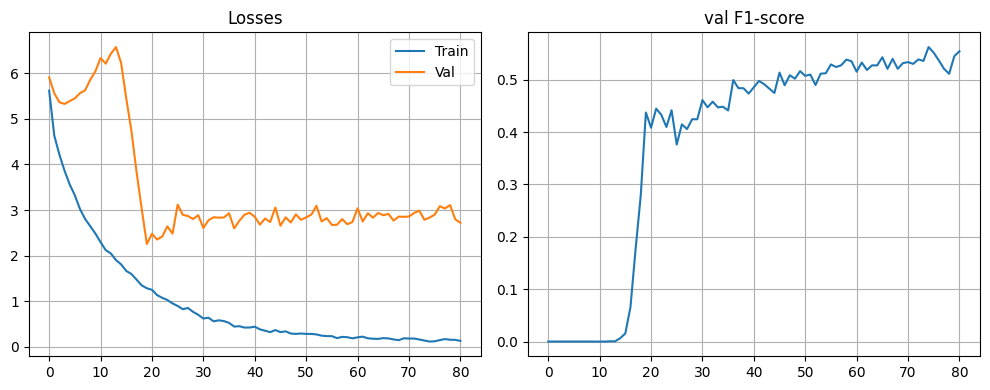

 82%|████████▏ | 82/100 [02:04<00:27,  1.52s/it]

Epoch 81: train_loss 0.1234695880577482, val_loss 2.7898376171405497, val_f1 0.5507525998676178


 83%|████████▎ | 83/100 [02:06<00:25,  1.51s/it]

Epoch 82: train_loss 0.12562604980735942, val_loss 2.8428567739633412, val_f1 0.547395193446174


 84%|████████▍ | 84/100 [02:07<00:24,  1.50s/it]

Epoch 83: train_loss 0.12447433738872923, val_loss 2.8871308106642504, val_f1 0.5486575625315979


 85%|████████▌ | 85/100 [02:09<00:22,  1.52s/it]

Epoch 84: train_loss 0.1387764878314117, val_loss 2.8900291186112623, val_f1 0.5416702820808723


 86%|████████▌ | 86/100 [02:10<00:21,  1.51s/it]

Epoch 85: train_loss 0.14733877932203227, val_loss 2.929937564409696, val_f1 0.5390023415182704


 87%|████████▋ | 87/100 [02:12<00:19,  1.52s/it]

Epoch 86: train_loss 0.1302449662109901, val_loss 3.0050819286933312, val_f1 0.5478667821740489


 88%|████████▊ | 88/100 [02:13<00:18,  1.51s/it]

Epoch 87: train_loss 0.15642147999385309, val_loss 2.986461584384625, val_f1 0.5375507293270957


 89%|████████▉ | 89/100 [02:15<00:16,  1.50s/it]

Epoch 88: train_loss 0.13597932573536348, val_loss 2.915723910698524, val_f1 0.5595762704241065


 90%|█████████ | 90/100 [02:16<00:14,  1.49s/it]

Epoch 89: train_loss 0.14561505679940356, val_loss 2.8835990062126746, val_f1 0.5519893843924542
Epoch 90: train_loss 0.12981630784684214, val_loss 2.9084548950195312, val_f1 0.5486247415420137


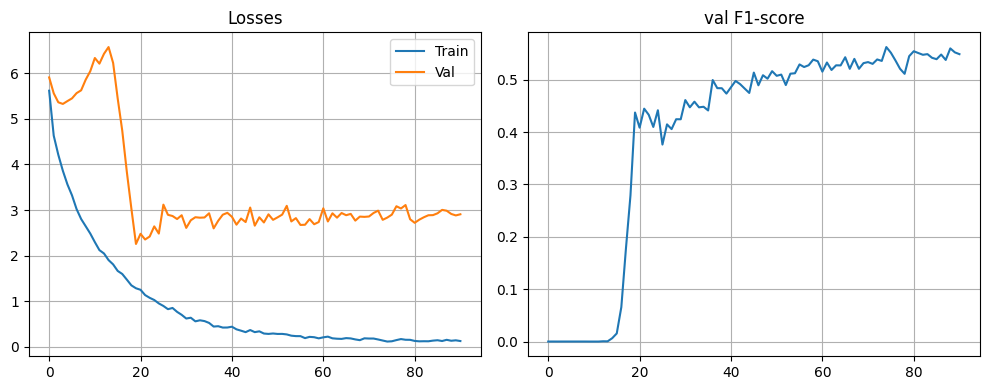

 92%|█████████▏| 92/100 [02:19<00:12,  1.52s/it]

Epoch 91: train_loss 0.1584824951815194, val_loss 2.8712253937354455, val_f1 0.552076917003869


 93%|█████████▎| 93/100 [02:21<00:10,  1.51s/it]

Epoch 92: train_loss 0.1442403328315965, val_loss 2.882743321932279, val_f1 0.5476062548908092


 94%|█████████▍| 94/100 [02:22<00:09,  1.51s/it]

Epoch 93: train_loss 0.11266533259687753, val_loss 2.857423874048086, val_f1 0.5357495752595965


 95%|█████████▌| 95/100 [02:24<00:07,  1.50s/it]

Epoch 94: train_loss 0.10333688158927293, val_loss 2.9646583520449123, val_f1 0.5419328433026654


 96%|█████████▌| 96/100 [02:25<00:06,  1.50s/it]

Epoch 95: train_loss 0.11511331462654574, val_loss 2.747553641979511, val_f1 0.5583661326562905


 97%|█████████▋| 97/100 [02:27<00:04,  1.50s/it]

Epoch 96: train_loss 0.09994641023463216, val_loss 2.977698747928326, val_f1 0.5431400172969224


 98%|█████████▊| 98/100 [02:28<00:03,  1.50s/it]

Epoch 97: train_loss 0.13565900729134164, val_loss 2.9967824862553525, val_f1 0.5278862352964249


 99%|█████████▉| 99/100 [02:30<00:01,  1.50s/it]

!!! NEW BEST MODEL !!!
Epoch 98: train_loss 0.11257091048976471, val_loss 2.8253536774561954, val_f1 0.5624891037073038
Epoch 99: train_loss 0.096248305563269, val_loss 2.8947260746589074, val_f1 0.5503500632504933


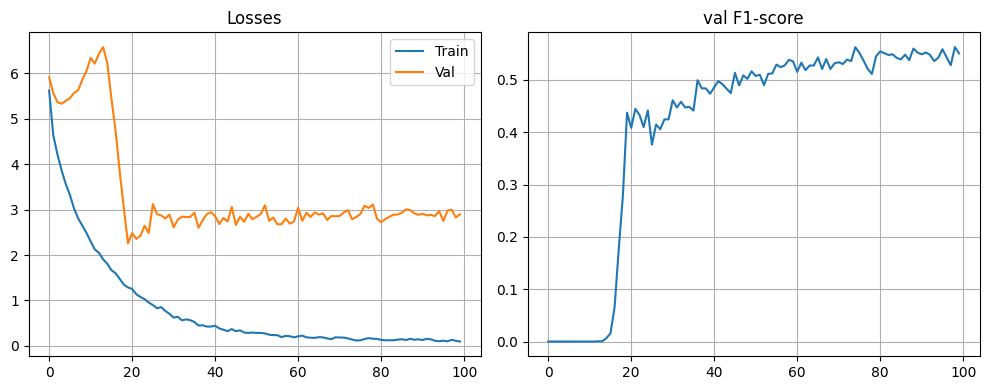

100%|██████████| 100/100 [02:31<00:00,  1.52s/it]

Best score: 0.5624891037073038


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [20]:
model = ic(torchvision.models.mobilenet_v3_small())
model.fc = nn.Linear(1024, 150)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_loop(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    model_name="best_model_002.pth"
)


## Inference

In [23]:
model = ic(PockemonModel(
    img_shape=IN_SHAPE,
    in_ch=3,
    hidden_ch=[32, 64, 128, 256],
    hidden_fc=[],
    out_dim=150,
    conv_dropout=0.1
))
model.load_state_dict(torch.load('./models/best_model_003.pth'))

ic| PockemonModel(
        img_shape=IN_SHAPE,
        in_ch=3,
        hidden_ch=[32, 64, 128, 256],
        hidden_fc=[],
        out_dim=150,
        conv_dropout=0.1
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (5): ReLU()
           (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (7): Dropout2d(p=0.1, inplace=False)
           (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (10): ReLU()
           (11): MaxPool2d(kernel

<All keys matched successfully>

In [24]:
df_ss = pd.read_csv("./data/sample_submission.csv")
df_ss.head()

,id,label
0,9553b359,Pikachu
1,c6bcf2c2,Pikachu
2,5493d25f,Pikachu
3,f17f13b5,Pikachu
4,bb4e5386,Pikachu


In [25]:
test_dataset[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.0837, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.0837, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.0837, -2.1179],
          ...,
          [-2.1179, -2.1008, -2.1008,  ..., -1.2103, -1.1932, -1.7240],
          [-2.1179, -2.1008, -2.1008,  ..., -1.2617, -1.3987, -1.7925],
          [-2.1179, -2.0837, -2.0837,  ..., -1.3987, -1.3987, -1.7754]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -1.9657, -1.9657, -2.0182],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -1.9657, -2.0182],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -1.9657, -2.0182],
          ...,
          [-2.0182, -1.9657, -1.9657,  ..., -0.2150, -0.3725, -1.2829],
          [-2.0182, -1.9482, -1.9482,  ..., -0.2850, -0.6001, -1.3529],
          [-2.0007, -1.9482, -1.9307,  ..., -0.4076, -0.6001, -1.3529]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.5256, -1.5256, -1.5779],
          [-1.8044, -1.8044,

In [26]:
pred_dict = dict()

model.eval()
with torch.no_grad():
    for i in trange(len(test_dataset)):
        X, y = test_dataset[i]
        X = X.unsqueeze(0)
        id = test_dataset.df.iloc[i]['id']
        pred = model(X).argmax().numpy()
        pred_dict[id] = label_encoder.inverse_transform([pred])[0]

100%|██████████| 1748/1748 [00:07<00:00, 231.32it/s]


In [27]:
df_ss['label'] = df_ss['id'].map(pred_dict)
df_ss.to_csv("./subm.csv", index=False)
df_ss.head()

,id,label
0,9553b359,Zubat
1,c6bcf2c2,Primeape
2,5493d25f,Squirtle
3,f17f13b5,Krabby
4,bb4e5386,Hypno
